# ColabFold

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import os
# only load this one time per session
if 'NOTEBOOK_INITIALIZED' not in globals():
    os.chdir(os.path.dirname(os.path.abspath('.')))
    NOTEBOOK_INITIALIZED = True


import src.utils as utils
import src.config as config
import src.haplosaurus as hs
import src.vep_pipeline as vp
import src.vep_analysis as va
import src.vep_metrics as vm
import src.analysis.attributions as ab
import src.proteingym as pg 
import src.onekg as og

import matplotlib.pyplot as plt
import seaborn as sns
import pooch
from tqdm import tqdm
import polars as pl
import glob

import src.colabfold.colabfold as cf
import src.biopython as bp
import src.vep_pipeline as vp

pd.set_option('display.max_columns', None)

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(


In [2]:
vep_files = va.list_vep_files(as_df=True)
vep_files.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep


Finding VEP files:   0%|          | 0/1 [00:00<?, ?it/s]

Found 1113266 parquet files in /home/schilder/projects/data/1KG/vep
Unique values:
>> model_location: 9
scoring_strategy: 3
variant_set: 1
haplotype: 111457
protein: 2251


,file,protein,haplotype,variant_set,model_location,scoring_strategy
0,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
1,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:REF,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
2,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals
3,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:54S>L,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,masked-marginals
4,/home/schilder/projects/data/1KG/vep/esm2_t12_...,NP_055800.2,ENSP00000382271:914L>V,clinical_ProteinGym_substitutions,esm2_t12_35M_UR50D,wt-marginals


## Get mean pLDDT for all ProteinGym proteins 

Get all the UniProt IDs from the ProteinGym mapping file.

In [3]:
pg_map = pg.get_mapping_file()

In [4]:
plddt_df = cf.get_plddt_all(protein_ids=pg_map["Uniprot_acc(HGNC/Uniprot)"].unique(), 
                            cache_only=True) 

100%|██████████| 532/532 [00:01<00:00, 391.12it/s]


,pLDDT_mean
count,532.000000
mean,78.011704
std,12.620485
min,38.655870
25%,69.493519
50%,80.334197
75%,88.225112
max,98.415979


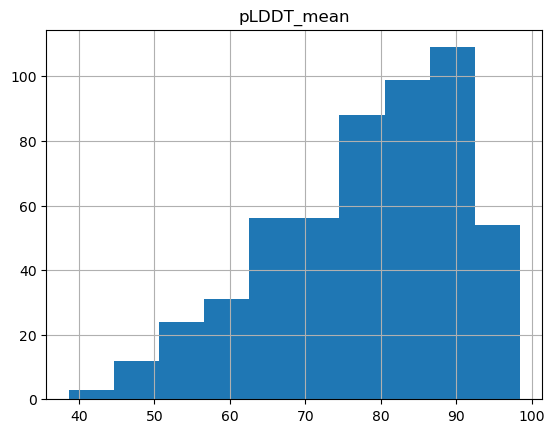

In [5]:
plddt_mean = plddt_df.groupby("uniprot_id")["pLDDT"].mean().sort_values(ascending=False).reset_index(name="pLDDT_mean")
plddt_mean.hist()

plddt_mean.describe()

In [6]:
top_plddt_proteins = pg_map.merge(
    plddt_mean.loc[plddt_mean["pLDDT_mean"] > 90][["uniprot_id", "pLDDT_mean"]],
    left_on="Uniprot_acc(HGNC/Uniprot)",
    right_on="uniprot_id",
    how="inner"
)
# Add the number of haplotypes for each protein
n_haplotypes = vep_files.groupby("protein")["haplotype"].nunique().reset_index(name="n_haplotypes")
top_plddt_proteins = top_plddt_proteins.merge(n_haplotypes, left_on="protein", right_on="protein", how="inner")
top_plddt_proteins["HGNC"] = top_plddt_proteins["GENEINFO"].str.split(":").str[0]

print(top_plddt_proteins.shape)
print("proteins with pLDDT>90: ", top_plddt_proteins["protein"].nunique())
top_plddt_proteins.head()

(1662, 854)
proteins with pLDDT>90:  88


,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,protein,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,mutant,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,protein_sequence,mutated_sequence,ClinSigSimple,aaref,aaalt,rs_dbSNP,hg19_chr,hg19_pos(1-based),hg18_chr,hg18_pos(1-based),aapos,genename,Ensembl_geneid,Ensembl_transcriptid,Ensembl_proteinid,Uniprot_acc,Uniprot_entry,HGVSc_ANNOVAR,HGVSp_ANNOVAR,HGVSc_snpEff,HGVSp_snpEff,HGVSc_VEP,HGVSp_VEP,APPRIS,GENCODE_basic,TSL,VEP_canonical,cds_strand,refcodon,codonpos,codon_degeneracy,Ancestral_allele,AltaiNeandertal,Denisova,VindijiaNeandertal,ChagyrskayaNeandertal,SIFT_score,SIFT_converted_rankscore,SIFT_pred,SIFT4G_score,SIFT4G_converted_rankscore,SIFT4G_pred,Polyphen2_HDIV_score,Polyphen2_HDIV_rankscore,Polyphen2_HDIV_pred,Polyphen2_HVAR_score,Polyphen2_HVAR_rankscore,Polyphen2_HVAR_pred,LRT_score,LRT_converted_rankscore,LRT_pred,LRT_Omega,MutationTaster_score,MutationTaster_converted_rankscore,MutationTaster_pred,MutationTaster_model,MutationTaster_AAE,MutationAssessor_score,MutationAssessor_rankscore,MutationAssessor_pred,FATHMM_score,FATHMM_converted_rankscore,FATHMM_pred,PROVEAN_score,PROVEAN_converted_rankscore,PROVEAN_pred,VEST4_score,VEST4_rankscore,MetaSVM_score,MetaSVM_rankscore,MetaSVM_pred,MetaLR_score,MetaLR_rankscore,MetaLR_pred,Reliability_index,MetaRNN_score,MetaRNN_rankscore,MetaRNN_pred,M-CAP_score,M-CAP_rankscore,M-CAP_pred,REVEL_score,REVEL_rankscore,MutPred_score,MutPred_rankscore,MutPred_protID,MutPred_AAchange,MutPred_Top5features,MVP_score,MVP_rankscore,gMVP_score,gMVP_rankscore,MPC_score,MPC_rankscore,PrimateAI_score,PrimateAI_rankscore,PrimateAI_pred,DEOGEN2_score,DEOGEN2_rankscore,DEOGEN2_pred,BayesDel_addAF_score,BayesDel_addAF_rankscore,BayesDel_addAF_pred,BayesDel_noAF_score,BayesDel_noAF_rankscore,BayesDel_noAF_pred,ClinPred_score,ClinPred_rankscore,ClinPred_pred,LIST-S2_score,LIST-S2_rankscore,LIST-S2_pred,VARITY_R_score,VARITY_R_rankscore,VARITY_ER_score,VARITY_ER_rankscore,VARITY_R_LOO_score,VARITY_R_LOO_rankscore,VARITY_ER_LOO_score,VARITY_ER_LOO_rankscore,Aloft_Fraction_transcripts_affected,Aloft_prob_Tolerant,Aloft_prob_Recessive,Aloft_prob_Dominant,Aloft_pred,Aloft_Confidence,CADD_raw,CADD_raw_rankscore,CADD_phred,CADD_raw_hg19,CADD_raw_rankscore_hg19,CADD_phred_hg19,DANN_score,DANN_rankscore,fathmm-MKL_coding_score,fathmm-MKL_coding_rankscore,fathmm-MKL_coding_pred,fathmm-MKL_coding_group,fathmm-XF_coding_score,fathmm-XF_coding_rankscore,fathmm-XF_coding_pred,Eigen-raw_coding,Eigen-raw_coding_rankscore,Eigen-phred_coding,Eigen-PC-raw_coding,Eigen-PC-raw_coding_rankscore,Eigen-PC-phred_coding,GenoCanyon_score,GenoCanyon_rankscore,integrated_fitCons_score,integrated_fitCons_rankscore,integrated_confidence_value,GM12878_fitCons_score,GM12878_fitCons_rankscore,GM12878_confidence_value,H1-hESC_fitCons_score,H1-hESC_fitCons_rankscore,H1-hESC_confidence_value,HUVEC_fitCons_score,HUVEC_fitCons_rankscore,HUVEC_confidence_value,LINSIGHT,LINSIGHT_rankscore,GERP++_NR,GERP++_RS,GERP++_RS_rankscore,phyloP100way_vertebrate,phyloP100way_vertebrate_rankscore,phyloP470way_mammalian,phyloP470way_mammalian_rankscore,phyloP17way_primate,phyloP17way_primate_rankscore,phastCons100way_vertebrate,phastCons100way_vertebrate_rankscore,phastCons470way_mammalian,phastCons470way_mammalian_rankscore,phastCons17way_primate,phastCons17way_primate_rankscore,SiPhy_29way_pi,SiPhy_29way_logOdds,SiPhy_29way_logOdds_rankscore,bStatistic,bStatistic_converted_rankscore,1000Gp3_AC,1000Gp3_AF,1000Gp3_AFR_AC,1000Gp3_AFR_AF,1000Gp3_EUR_AC,1000Gp3_EUR_AF,1000Gp3_AMR_AC,1000Gp3_AMR_AF,1000Gp3_EAS_AC,1000G

In [7]:
for id_type in ["HGNC","protein","Ensembl_transcriptid", "Ensembl_proteinid"]:
    print(id_type)
    print(top_plddt_proteins.loc[top_plddt_proteins["n_haplotypes"] > 100][id_type].unique())
    print("-"*100)

HGNC
['DPYD' 'AGL' 'CPS1']
----------------------------------------------------------------------------------------------------
protein
['NP_000101.2' 'NP_000633.2' 'NP_001866.2']
----------------------------------------------------------------------------------------------------
Ensembl_transcriptid
['ENST00000370192' 'ENST00000361915' 'ENST00000417946' 'ENST00000233072']
----------------------------------------------------------------------------------------------------
Ensembl_proteinid
['ENSP00000359211' 'ENSP00000355106' 'ENSP00000388496' 'ENSP00000233072']
----------------------------------------------------------------------------------------------------


In [15]:
# refseq_ids = ['NP_009225.1'] # BRCA1
# refseq_ids = ['NP_000101.2'] # DYPD 
refseq_ids =  ['NP_000537.3'] # TP53
# refseq_ids = top_plddt_proteins.loc[top_plddt_proteins["n_haplotypes"] > 100]["protein"].unique()[0:1]

vep_df = va.merge_vep(
    scoring_strategy=["masked-marginals"],
    vep_files=vep_files.loc[(vep_files['model_location']=="esm1_t34_670M_UR50D") & 
                            (vep_files['protein'].isin(refseq_ids))]
    )
vep_df["HGNC"] = vep_df["GENEINFO"].str.split(":").str[0] 
vep_df["site"] = vep_df["protein"] + ":" + vep_df["mutant"] 
print("n_ENST: ", vep_df["ENST"].nunique())
print("n_haplotypes: ", vep_df["haplotype"].nunique())
print("n_sites: ", vep_df["site"].nunique())

vep_df.head()

No save_dir provided, using: /home/schilder/projects/data/1KG/vep
Found 26 masked-marginals parquet files


Reading files:   0%|          | 0/26 [00:00<?, ?it/s]

Concatenating VEP dataframes
Loading ==> /home/schilder/projects/data/haplosaurus/tx_id_map.pkl


Loading '/home/schilder/projects/data/haplosaurus/tx_id_map.pkl': 100%|██████████| 1.70M/1.70M [00:00<00:00, 7.90GB/s]


VEP dataframe shape: (7046, 73)
n_ENST:  1
n_haplotypes:  26
n_sites:  271


,haplotype,protein,protein_sequence,mutant,mutated_sequence,DMS_bin_score,VEP,scoring_strategy,is_ref,model_location,variant_set,ENSP,ENST,mutant_in_haplotype,site,#CHROM,POS,ID,REF,ALT,QUAL,FILTER,#Uploaded_variation,Location,Allele,Gene,Feature,Feature_type,Consequence,cDNA_position,CDS_position,Protein_position,Amino_acids,Codons,Existing_variation,IMPACT,DISTANCE,STRAND,FLAGS,REFSEQ_MATCH,REFSEQ_OFFSET,GIVEN_REF,USED_REF,BAM_EDIT,HGVSc,HGVSp,HGVS_OFFSET,AF_ESP,AF_EXAC,ALLELEID,CLNDISDB,CLNDN,CLNHGVS,CLNREVSTAT,CLNSIG,CLNSIGCONF,CLNVC,CLNVCSO,GENEINFO,MC,ORIGIN,RS,AF_TGP,CLNVI,CLNDISDBINCL,CLNDNINCL,CLNSIGINCL,EVH_epistatic,EVH_independent,ESM1V_ensemble_mean,Tranception,model_count,clinsig,HGNC
0,ENSP00000269305:47P>S,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,D393Y,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,Benign,-2.450665,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000269305,ENST00000269305,False,NP_000537.3:D393Y,17,7669614,1741120,C,A,.,PASS,1741120,17:7669614,A,7157,NM_000546.6,Transcript,missense_variant,1319,1177,393,D/Y,Gac/Tac,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000546.6:c.1177G>T,NP_000537.3:p.Asp393Tyr,-,NaN,NaN,1808497,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.7669614C>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,TP53:7157,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,NaN,NaN,NaN,NaN,NaN,NaN,-7.854937,-9.616399,-2.425277,-0.005525,9,likely_benign,TP53
1,ENSP00000269305:47P>S,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,E388D,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,Benign,-1.935475,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000269305,ENST00000269305,False,NP_000537.3:E388D,17,7669627,1737684,T,A,.,PASS,1737684,17:7669627,A,7157,NM_000546.6,Transcript,missense_variant,1306,1164,388,E/D,gaA/gaT,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000546.6:c.1164A>T,NP_000537.3:p.Glu388Asp,-,NaN,NaN,1787548,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.7669627T>A,"criteria_provided,_single_submitter",Likely_benign,NaN,single_nucleotide_variant,SO:0001483,TP53:7157,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,NaN,NaN,NaN,NaN,NaN,NaN,-3.815515,-2.777724,-0.569765,-0.004054,9,likely_benign,TP53
2,ENSP00000269305:47P>S,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,E388A,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,Benign,-2.454219,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000269305,ENST00000269305,False,NP_000537.3:E388A,17,7669628,141425,T,G,.,PASS,141425,17:7669628,G,7157,NM_000546.6,Transcript,missense_variant,1305,1163,388,E/A,gAa/gCa,-,MODERATE,-,-1,-,-,-,T,T,-,NM_000546.6:c.1163A>C,NP_000537.3:p.Glu388Ala,-,NaN,NaN,151139,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome|not_pr...,NC_000017.11:g.7669628T>G,reviewed_by_expert_panel,Likely_benign,NaN,single_nucleotide_variant,SO:0001483,TP53:7157,"SO:0001583|missense_variant,SO:0001624|3_prime...",1,587781736,NaN,ClinGen:CA000047,NaN,NaN,NaN,-5.192806,-4.849092,-0.850681,-0.008491,9,likely_benign,TP53
3,ENSP00000269305:47P>S,NP_000537.3,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,E388Q,MEEPQSDPSVEPPLSQETFSDLWKLLPENNVLSPLPSQAMDDLMLS...,Benign,-2.890538,masked-marginals,False,esm1_t34_670M_UR50D,clinical_ProteinGym_substitutions,ENSP00000269305,ENST00000269305,False,NP_000537.3:E388Q,17,7669629,1737291,C,G,.,PASS,1737291,17:7669629,G,7157,NM_000546.6,Transcript,missense_variant,1304,1162,388,E/Q,Gaa/Caa,-,MODERATE,-,-1,-,-,-,C,C,-,NM_000546.6:c.1162G>C,NP_000537.3:p.Glu388Gln,-,NaN,NaN,1790490,"MONDO:MONDO:0015356,MeSH:D009386,MedGen:C00276...",Hereditary_cancer-predisposing_syndrome,NC_000017.11:g.7669629C>G,"criteria_provided,_single_submitter",Likely_benign,NaN,s

### Merge haplotypes

In [10]:
haplotypes_hgdp = hs.get_haplotypes(cache = hs.DIR_DICT["HGDP_haplotypes"],
                                     tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes_1kg = hs.get_haplotypes(cache = hs.DIR_DICT["haplotypes"],
                                    tx_ids=vep_df['ENST'].unique(), 
                                    cache_only = True) 
haplotypes = hs.merge_haplotype_datasets({"1KG":haplotypes_1kg, "HGDP":haplotypes_hgdp},
                                         tx_id_method = "intersection",
                                         use_deepcopy = True)

Found haplotypes of 85520 transcripts in: '/home/schilder/projects/data/Human_Genome_Diversity_Project/haplosaurus/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Found haplotypes of 47329 transcripts in: '/home/schilder/.cache/ensembl_rest/haplotypes/'


Getting haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Using deepcopy
Merging 1 tx_ids using intersection


Merging haplotype datasets:   0%|          | 0/2 [00:00<?, ?it/s]

Merging haplotypes:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Merged 26 haplotypes across 1 tx_ids.


Convert haplotypes to fasta and run colabfold.

In [11]:
merged_fasta = {}
for tx_id in haplotypes.keys():
    print(tx_id)
    
    # REF only
    hs.haplotypes_to_fasta(haplotypes=hs.get_haplotype_ref(haplotypes, keep_structure=True),  
                           tx_ids=[tx_id],
                            save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}_REF"), 
                            split_subdir="",
                            add_missing_ref=False,
                            # force=True,
                            compress=False)
    # All haplotypes
    merged_fasta.update(
        hs.haplotypes_to_fasta(haplotypes=haplotypes,  
                           tx_ids=[tx_id],
                            save_dir=os.path.expanduser(f"~/projects/data/colabfold/{tx_id}"), 
                            split_subdir="",
                            # force=True,
                            compress=False)
    )

ENST00000269305


Processing transcripts:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to split FASTAs:   0%|          | 0/1 [00:00<?, ?it/s]

Adding reference haplotype:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype sequences:   0%|          | 0/1 [00:00<?, ?it/s]

Getting haplotype names:   0%|          | 0/1 [00:00<?, ?it/s]

## Create MSA for each haplotype

You can run ColabFold to get the MSA for the REF first, and then use this REF MSA as a template.

In [ ]:
%%capture

!cd ~/projects/data/colabfold/ENST00000370192_REF
!colabfold_batch --msa-only ENST00000370192.fasta .

In [12]:
viable_templates = [x for x in glob.glob(os.path.expanduser(f"~/projects/data/colabfold/{tx_id}_REF/*.a3m"))]
print("Using template: ", viable_templates[0])

Using template:  /home/schilder/projects/data/colabfold/ENST00000269305_REF/ENSP00000269305_REF.a3m


Alternatively, you can use the ProteinGym-provided MSA as a template. 

However, these are in a2m format and may not be reliably formatted for ColabFold (which requires a3m as input)

Create MSAs for colabfold using the same MSA template for all sequences.

In [13]:
# viable_templates = [x for x in glob.glob(os.path.expanduser("~/projects/data/ProteinGym/subs/*.a2m")) if vep_df["HGNC"].unique()[0] in x or x in vep_df["protein"].unique()[0]]
# print("Using template: ", viable_templates[0])

In [ ]:
haplotype_msas = cf.create_haplotype_msas(
    template_msa=viable_templates[0], 
    haplotypes_fasta=f"~/projects/data/colabfold/{tx_id}/{tx_id}.fasta",  
    description_prefix="1000_Genomes_on_GRCh38-Haplosaurus-",
    output_dir=f"~/projects/data/colabfold/{tx_id}/af2_sameMSA",
    force=True,
    )
print(len(haplotype_msas),"haplotype MSAs created")

/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/Bio/SeqIO/FastaIO.py:203: BiopythonDeprecationWarning: Previously, the FASTA parser silently ignored comments at the beginning of the FASTA file (before the first sequence).

Nowadays, the FASTA file format is usually understood not to have any such comments, and most software packages do not allow them. Therefore, the use of comments at the beginning of a FASTA file is now deprecated in Biopython.

In a future Biopython release, this deprecation warning will be replaced by a ValueError. To avoid this, there are three options:

(1) Modify your FASTA file to remove such comments at the beginning of the file.

(2) Use SeqIO.parse with the 'fasta-pearson' format instead of 'fasta'. This format is consistent with the FASTA format defined by William Pearson's FASTA aligner software. Thie format allows for comments before the first sequence; lines starting with the ';' character anywhere in the file are also regarded as comment lin

26 haplotype MSAs created


Now you can run the fulla ColabFold pipeline for get the AlphaFold2 predictions.

*NOTE*: Sometimes you'll get an error like `Segmentation fault (core dumped)` on the first try.   
If so, just run the `colabfold_batch` command again and it should work the second time.

In [ ]:
%%capture

!cd ~/projects/data/colabfold/ENST00000370192
!CUDA_VISIBLE_DEVICES=2 colabfold_batch --save-single-representations af2_sameMSA/ af2_sameMSA/

### Postprocessing & Compression

Compression is neccessry because the AF2 outputs can be massive, especially the residue-residue pair representation files ("*_pair_repr_*").

Compress all JSON and PDB files.

In [ ]:
# !find . -type f -name "*.json" -exec gzip {} +
# !find . -type f -name "*.pdb" -exec gzip {} +

In [ ]:
import os
import numpy as np
import glob
from tqdm import tqdm

force = True
for rep_type in ["_single_repr_", "_pair_repr_"]:

    # Expand the user path and format with tx_id
    base_dir = os.path.expanduser(f"~/projects/data/colabfold/")

    # List all folders (directories) within the base_dir
    tx_folders = [os.path.join(base_dir, f) for f in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, f))]
    

    subfolders = [os.path.join(tx_folder, d) 
              for tx_folder in tx_folders 
              for d in os.listdir(tx_folder) 
              if os.path.isdir(os.path.join(tx_folder, d))]

    for folder in subfolders:

        # Get the files
        files = glob.glob(os.path.expanduser(f"{folder}/*{rep_type}*.npy"))
        if len(files) == 0:
            print(f"No files found for {folder}")
            continue
        else:
            print(f"{folder} has {len(files)} files")
        
        # Get total file sizes
        total_size = sum(os.path.getsize(f) for f in files)
        print(f"Total size of {len(files)} files in {folder}: {total_size/1024/1024:.2f} MB")
        
        # Define the npz file
        npz_file = f"{folder}/{os.path.basename(files[0]).split("_")[0]}_{rep_type.strip('_')}.npz"
        
        # Check if the npz file exists
        if not os.path.exists(npz_file) or force:  
            # Collect the map arrays in a dictionary
            mmap_arrays = {}
            for i, file in tqdm(enumerate(files), total=len(files)):
                mmap_arrays[os.path.basename(file)] = np.load(file, mmap_mode='r+')
                
            # # You can then process and save chunks of this mmap_array
            # # For example, to compress a portion and save it as a new compressed NPY file:
            # # (This still involves loading a chunk into memory for compression)
            
            print(f"Saving {npz_file}")
            np.savez_compressed(npz_file, **mmap_arrays)

        # Get the size of the original files (already computed as total_size)
        # Get the size of the compressed npz file
        compressed_size = os.path.getsize(npz_file)
        print(f"Compressed file size: {compressed_size/1024/1024:.2f} MB")
        if total_size > 0:
            percent_compression = 100 * (1 - compressed_size / total_size)
            print(f"Percent compression: {percent_compression:.2f}%")
        else:
            print("Original total size is zero, cannot compute percent compression.")
        
        # # Read back in the compressed npz file to check its contents
        # loaded = np.load(npz_file, allow_pickle=True)
        # print(f"Keys in {npz_file}: {list(loaded.keys())}")
        # for k in loaded.files:
        #     print(f"Shape of {k}: {loaded[k].shape}")
        
        # # os.remove(file) 

/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym has 540 files
Total size of 540 files in /home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym: 491.29 MB


100%|██████████| 540/540 [00:00<00:00, 4588.63it/s]

Saving /home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym/ENSP00000350283_single_repr.npz


Compressed file size: 382.19 MB
Percent compression: 22.21%
/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA has 617 files
Total size of 617 files in /home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA: 561.34 MB


100%|██████████| 617/617 [00:00<00:00, 9577.56it/s]

...

100%|██████████| 783/783 [00:00<00:00, 9457.08it/s]

Saving /home/schilder/projects/data/colabfold/ENST00000370192/af2_sameMSA/ENSP00000359211_single_repr.npz


Compressed file size: 303.32 MB
Percent compression: 22.62%
No files found for /home/schilder/projects/data/colabfold/ENST00000370192_REF/ENSP00000359211_REF_env
No files found for /home/schilder/projects/data/colabfold/ENST00000357654_REF/ENSP00000350283_REF_env
/home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym has 539 files
Total size of 539 files in /home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym: 456724.80 MB


100%|██████████| 539/539 [00:00<00:00, 9211.98it/s]

Saving /home/schilder/projects/data/colabfold/ENST00000357654/af2_sameMSA_proteingym/ENSP00000350283_pair_repr.npz


In [ ]:
# Comrpess npy files to npz files:
tx_id = vep_df["ENST"].iloc[0]
for file in glob.glob(f"~/projects/data/colabfold/{tx_id}/af2_sameMSA_proteingym/*.npy"):
    data = np.load(file)
    np.savez_compressed(file.replace(".npy", ".npz"), data)
    # os.remove(file) 

## Import contact maps

Find PDB files

In [ ]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
tx_id = vep_df["ENST"].iloc[0]
pdb_files = cf.search_files(base_dir = base_dir,
                         tx_id = tx_id,
                         subdir = "af2_sameMSA",
                         suffix = ".pdb*",
                         model_number = 1) 

126 PDB files found


Import continuous inverrted distance maps.

In [7]:
contact_maps = cf.import_contact_maps(pdb_files,
                                      return_distance_map=True,
                                      continuous=True)


  0%|          | 0/126 [00:00<?, ?it/s]

100%|██████████| 126/126 [00:30<00:00,  4.07it/s]


In [8]:
# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps, 
                                                     msa=msa) 

Padding contact maps to MSA: 100%|██████████| 126/126 [00:03<00:00, 41.41it/s]


Import binarized contact maps.

In [12]:
contact_maps_binary = cf.import_contact_maps(pdb_files,
                                             return_distance_map=False,
                                             continuous=False)

  0%|          | 0/126 [00:00<?, ?it/s]

100%|██████████| 126/126 [00:31<00:00,  4.03it/s]


In [13]:
# Insert or add padding to each contact map (using the MSA as a guide)to make them all the same length
msa = bp.read_msa(merged_fasta[list(merged_fasta.keys())[0]], to_msa=True)
contact_maps_binary = cf.pad_all_contact_maps_to_msa(contact_maps=contact_maps_binary, 
                                                     msa=msa) 

Padding contact maps to MSA: 100%|██████████| 126/126 [00:03<00:00, 38.63it/s]


## Create population-weighted contact maps

For each superpopulation, weight the contacts maps according to their frequency in those populations.

Get frequency of each haplotype per superpopulation.

In [9]:
haps_to_samples = hs.haplotypes_to_samples(haplotypes=haplotypes,  
                                           as_df=True,
                                           add_sample_metadata=True,
                                           return_seqs=False, 
                                           add_ref=False, 
                                           duplicate_ref=False,
                                           verbose=True,
                                           )
haps_to_samples.head()

freq_df = hs.calculate_haplotype_frequency_per_superpop(
    haps_to_samples,
    cast=True, 
    verbose=True,
    add_specificity_cols=True
)
# freq_df.to_parquet("results/data/freq_df.parquet")
freq_df.head()

Extracting sample IDs:   0%|          | 0/1 [00:00<?, ?it/s]

Number of samples: 3938
Number of transcripts to process: 1


Processing sample to haplotype name maps:   0%|          | 0/1 [00:00<?, ?it/s]

Converting haplotypes to DataFrame
Adding sample metadata to the DataFrame
0 samples are missing superpopulation metadata
Samples before merging: 3826
Samples after merging: 3826
Final shape: (7860, 16)
>> haplotype(s): 144
>> cohort(s): 3
>> cohort_sample(s): 3938
>> sample(s): 3826
>> population(s): 158
>> superpopulation(s): 8
>> sex(s): 2
0 samples are missing superpopulation metadata

Number of variants specific to each superpopulation:
specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

Percentage of superpopulation-specific haplotypes: 81.94%


,haplotype,AFR_freq,AMR_freq,CSA_freq,EAS_freq,EUR_freq,MID_freq,OCE_freq,SAS_freq,AFR_samples,AMR_samples,CSA_samples,EAS_samples,EUR_samples,MID_samples,OCE_samples,SAS_samples,top_superpopulation,top_superpopulation_freq,superpopulation_count,specific_superpopulation,specific_superpopulation_samples
0,ENSP00000350283:1028R>H,0.000000,0.004902,0.0,0.0,0.000000,0.000000,0.0,0.000000,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,AMR,0.004902,1,AMR,4.0
1,"ENSP00000350283:1038E>G,1183K>R,1613S>G",0.000000,0.000000,0.0,0.0,0.000000,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,MID,0.003289,1,MID,1.0
2,"ENSP00000350283:1038E>G,1613S>G",0.000000,0.000000,0.0,0.0,0.003012,0.003289,0.0,0.000000,0.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,MID,0.003289,2,None,NaN
3,ENSP00000350283:1040S>N,0.000791,0.017157,0.0,0.0,0.020331,0.006579,0.0,0.000992,2.0,14.0,0.0,0.0,27.0,2.0,0.0,1.0,EUR,0.020331,5,None,NaN
4,ENSP00000350283:1099P>L,0.000000,0.000000,0.0,0.0,0.000000,0.000000,0.0,0.002976,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,SAS,0.002976,1,SAS,3.0


Subset by superpopulation-specific haplotypes.

In [10]:
freq_df["specific_superpopulation"].value_counts()

specific_superpopulation
AFR    41
EAS    20
SAS    16
AMR    14
EUR    13
MID     8
OCE     4
CSA     2
Name: count, dtype: int64

In [ ]:
# Get the pdb file for each haplotype
hap_id_dict = cf.get_haplotype_ids(contact_maps.keys(), as_dict=-1)
freq_df["pdb_file"] = freq_df['haplotype'].str.split(":").str[1].map(hap_id_dict)
freq_df_pdb = freq_df.set_index("pdb_file")
freq_df_pdb = freq_df_pdb[freq_df_pdb.index.notna()] 
# reorder freq_df_pdb to match contact_maps
freq_df_pdb.loc[[k for k in contact_maps.keys() if k in freq_df_pdb.index]]

freq_cols = [col for col in freq_df.columns if "freq" in col if col!="top_superpopulation_freq"]
specific_maps = {}
specific_diff_maps = {}
specific_binary_diff_maps = {}
specific_binary_diff_figs = {}

ref_key =  cf.get_ref_key(contact_maps)

for col in tqdm(freq_cols):
    pop = col.split("_")[0] 
    df = freq_df_pdb.loc[freq_df_pdb["specific_superpopulation"]==pop]
    pop_maps = [v for k,v in contact_maps.items() if k in df.index]
    specific_maps[pop] = cf.average_matrices(pop_maps, 
                                         weights=df[col].values,
                                         normalize_scale=False)  
    # Compute absolute difference, then mean
    # Take the diff of each map and then average the diffs
    # Stack the maps into a 3D array and use numpy for vectorized computation
    if pop_maps:
        diffs = np.stack(pop_maps) - contact_maps[ref_key]
        mean_div = np.mean(diffs, axis=0)
    else:
        mean_div = 0
    specific_diff_maps[pop] = mean_div 

    # Compute binary gain/loss maps
    diff_fig, diff_map = cf.plot_contact_map_diff({k:v for k,v in contact_maps_binary.items() if k in df.index or k==ref_key}, 
                                                              ref_key=ref_key,
                                                              show_plot=False,
                                                              verbose=False
                                                              )  
    specific_binary_diff_maps[pop] = diff_map 
    specific_binary_diff_figs[pop] = diff_fig
    

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]


NameError: name 'contact_maps_binary' is not defined

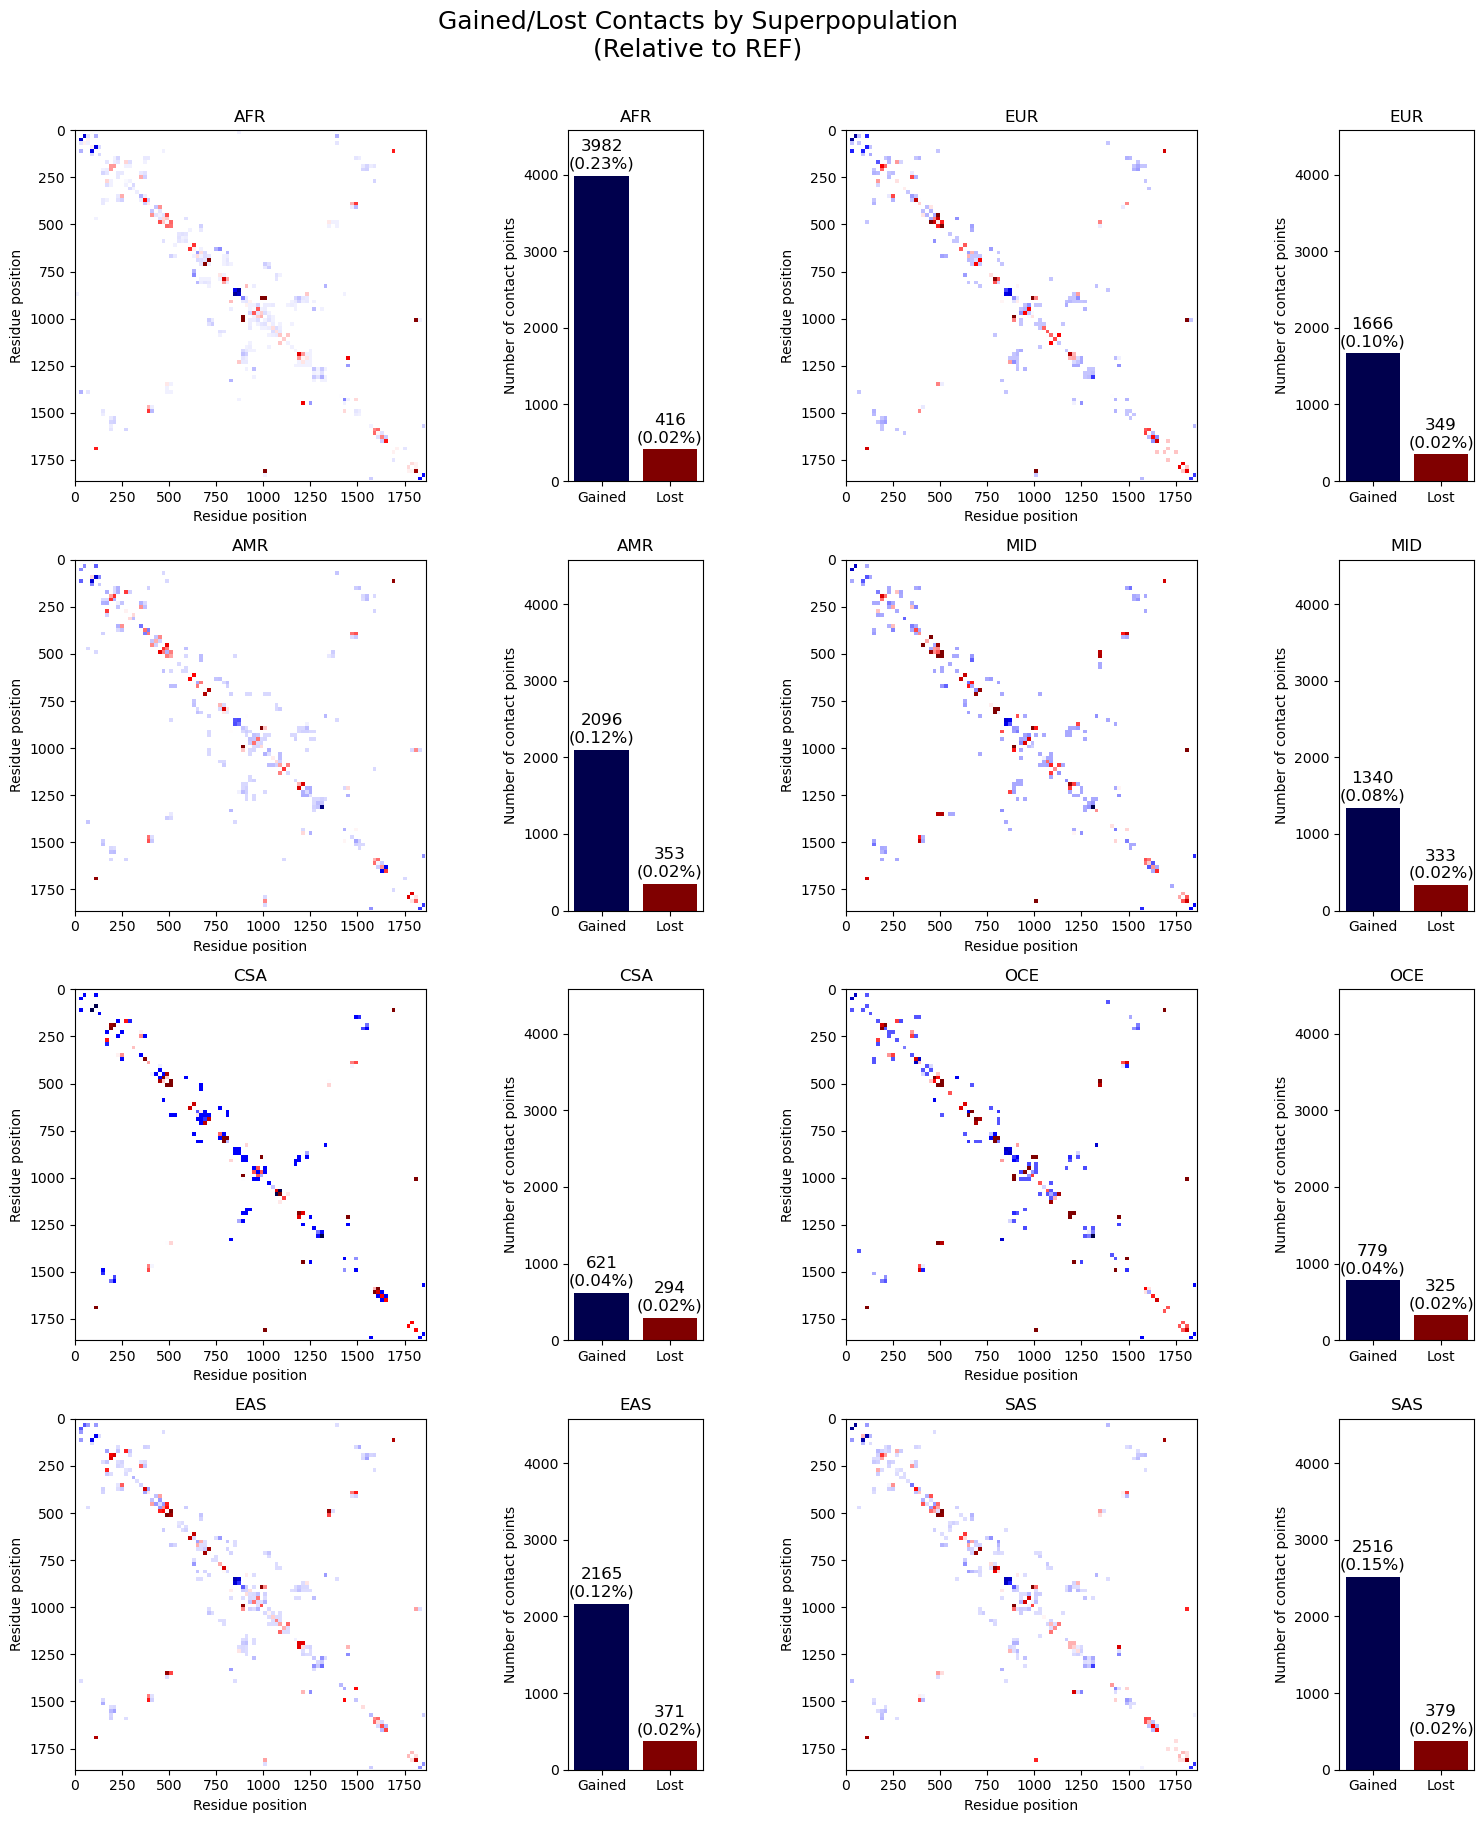

In [71]:
fig, bar_dfs = cf.plot_superpopulation_contact_diff(
    specific_binary_diff_figs,
    specific_binary_diff_maps,
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True
)

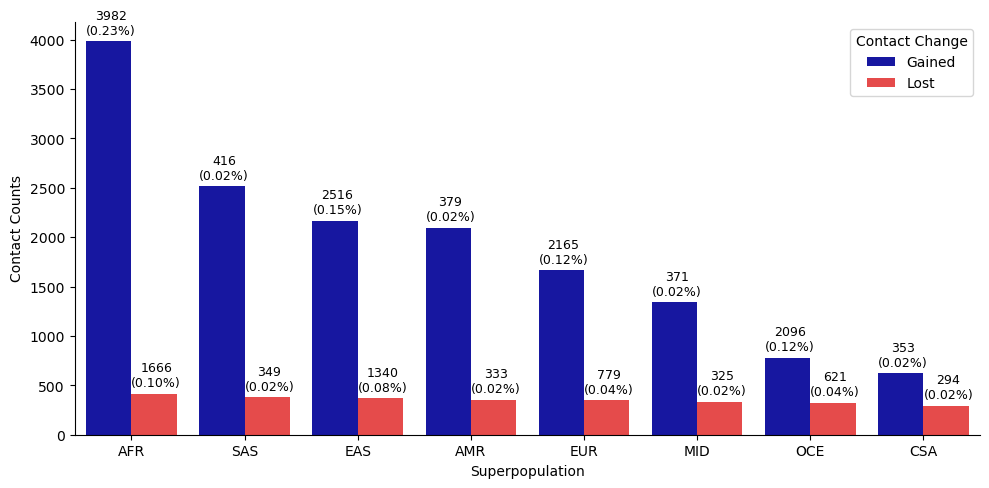

In [ ]:
bar_superop_fig, bar_superop_df = cf.plot_contact_map_diff_barplot_grouped(
    bar_dfs,
    group_by="superpopulation",
    figsize=(10, 5)
    )

Weighted by haplotype frequency.

In [ ]:
# Get the pdb file for each haplotype
hap_id_dict = cf.get_haplotype_ids(contact_maps.keys(), as_dict=-1)
freq_df["pdb_file"] = freq_df['haplotype'].str.split(":").str[1].map(hap_id_dict)
freq_df_pdb = freq_df.set_index("pdb_file")
freq_df_pdb = freq_df_pdb[freq_df_pdb.index.notna()] 
# reorder freq_df_pdb to match contact_maps
freq_df_pdb.loc[[k for k in contact_maps.keys() if k in freq_df_pdb.index]]

ref_key = cf.get_ref_key(contact_maps)

# For each superpopulation, average the contact maps weighted by the frequency of the haplotype in the superpopulation
freq_cols = [col for col in freq_df.columns if "freq" in col if col!="top_superpopulation_freq"]
avg_maps = {}
avg_binary_diff_maps = {}
avg_binary_diff_figs = {}

for col in tqdm(freq_cols):
    pop = col.split("_")[0] 
    pop_maps = [v for k,v in contact_maps.items() if k in freq_df_pdb.index]
    avg_maps[pop] = cf.mc.average_matrices(pop_maps, 
                                         weights=freq_df_pdb[col].values,
                                         normalize_scale=False,
                                         use_max=True)
    # Stack the maps into a 3D array and use numpy for vectorized computation
    if pop_maps:
        diffs = np.stack(pop_maps) - contact_maps[ref_key]
        mean_div = np.mean(diffs, axis=0)
    else:
        mean_div = 0
    specific_diff_maps[pop] = mean_div 

        # Compute binary gain/loss maps
    diff_fig, diff_map = cf.plot_contact_map_diff({k:v for k,v in contact_maps.items() if k in freq_df_pdb.index or k==ref_key}, 
                                                weights=freq_df_pdb.loc[~freq_df_pdb["haplotype"].str.endswith(":REF")][col].values,
                                                ref_key=ref_key,
                                                bin_size=30,
                                                show_plot=False,
                                                verbose=False
                                                )  
    avg_binary_diff_maps[pop] = diff_map 
    avg_binary_diff_figs[pop] = diff_fig
    

100%|██████████| 8/8 [00:27<00:00,  3.42s/it]


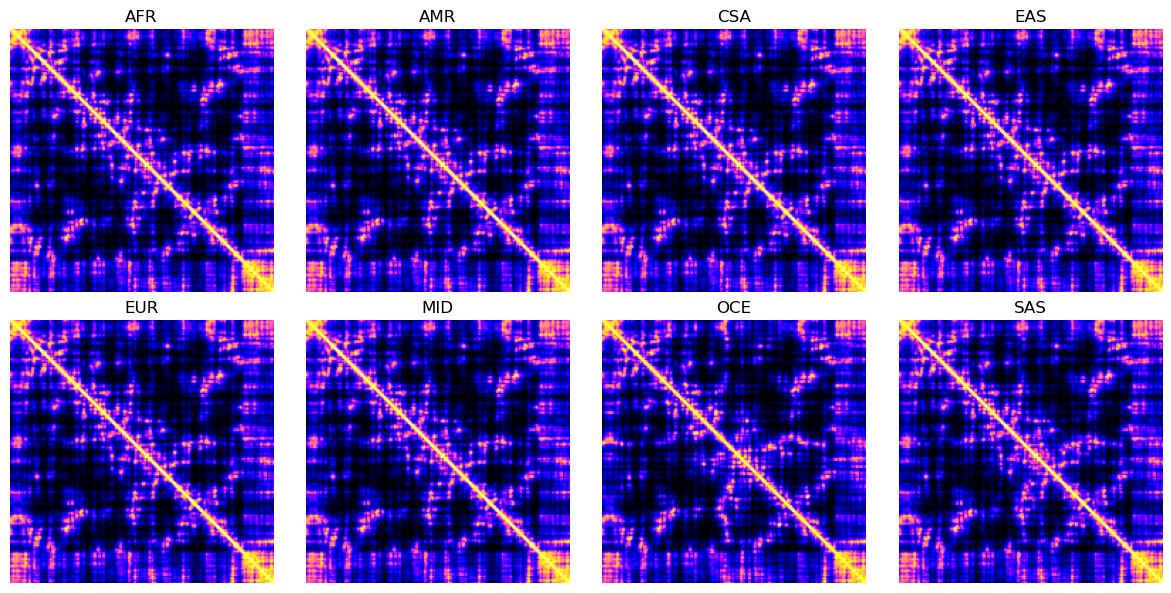

In [160]:
cf.plot_superpopulation_maps(avg_maps, pow=4, nrows=2, cmap='gnuplot2')


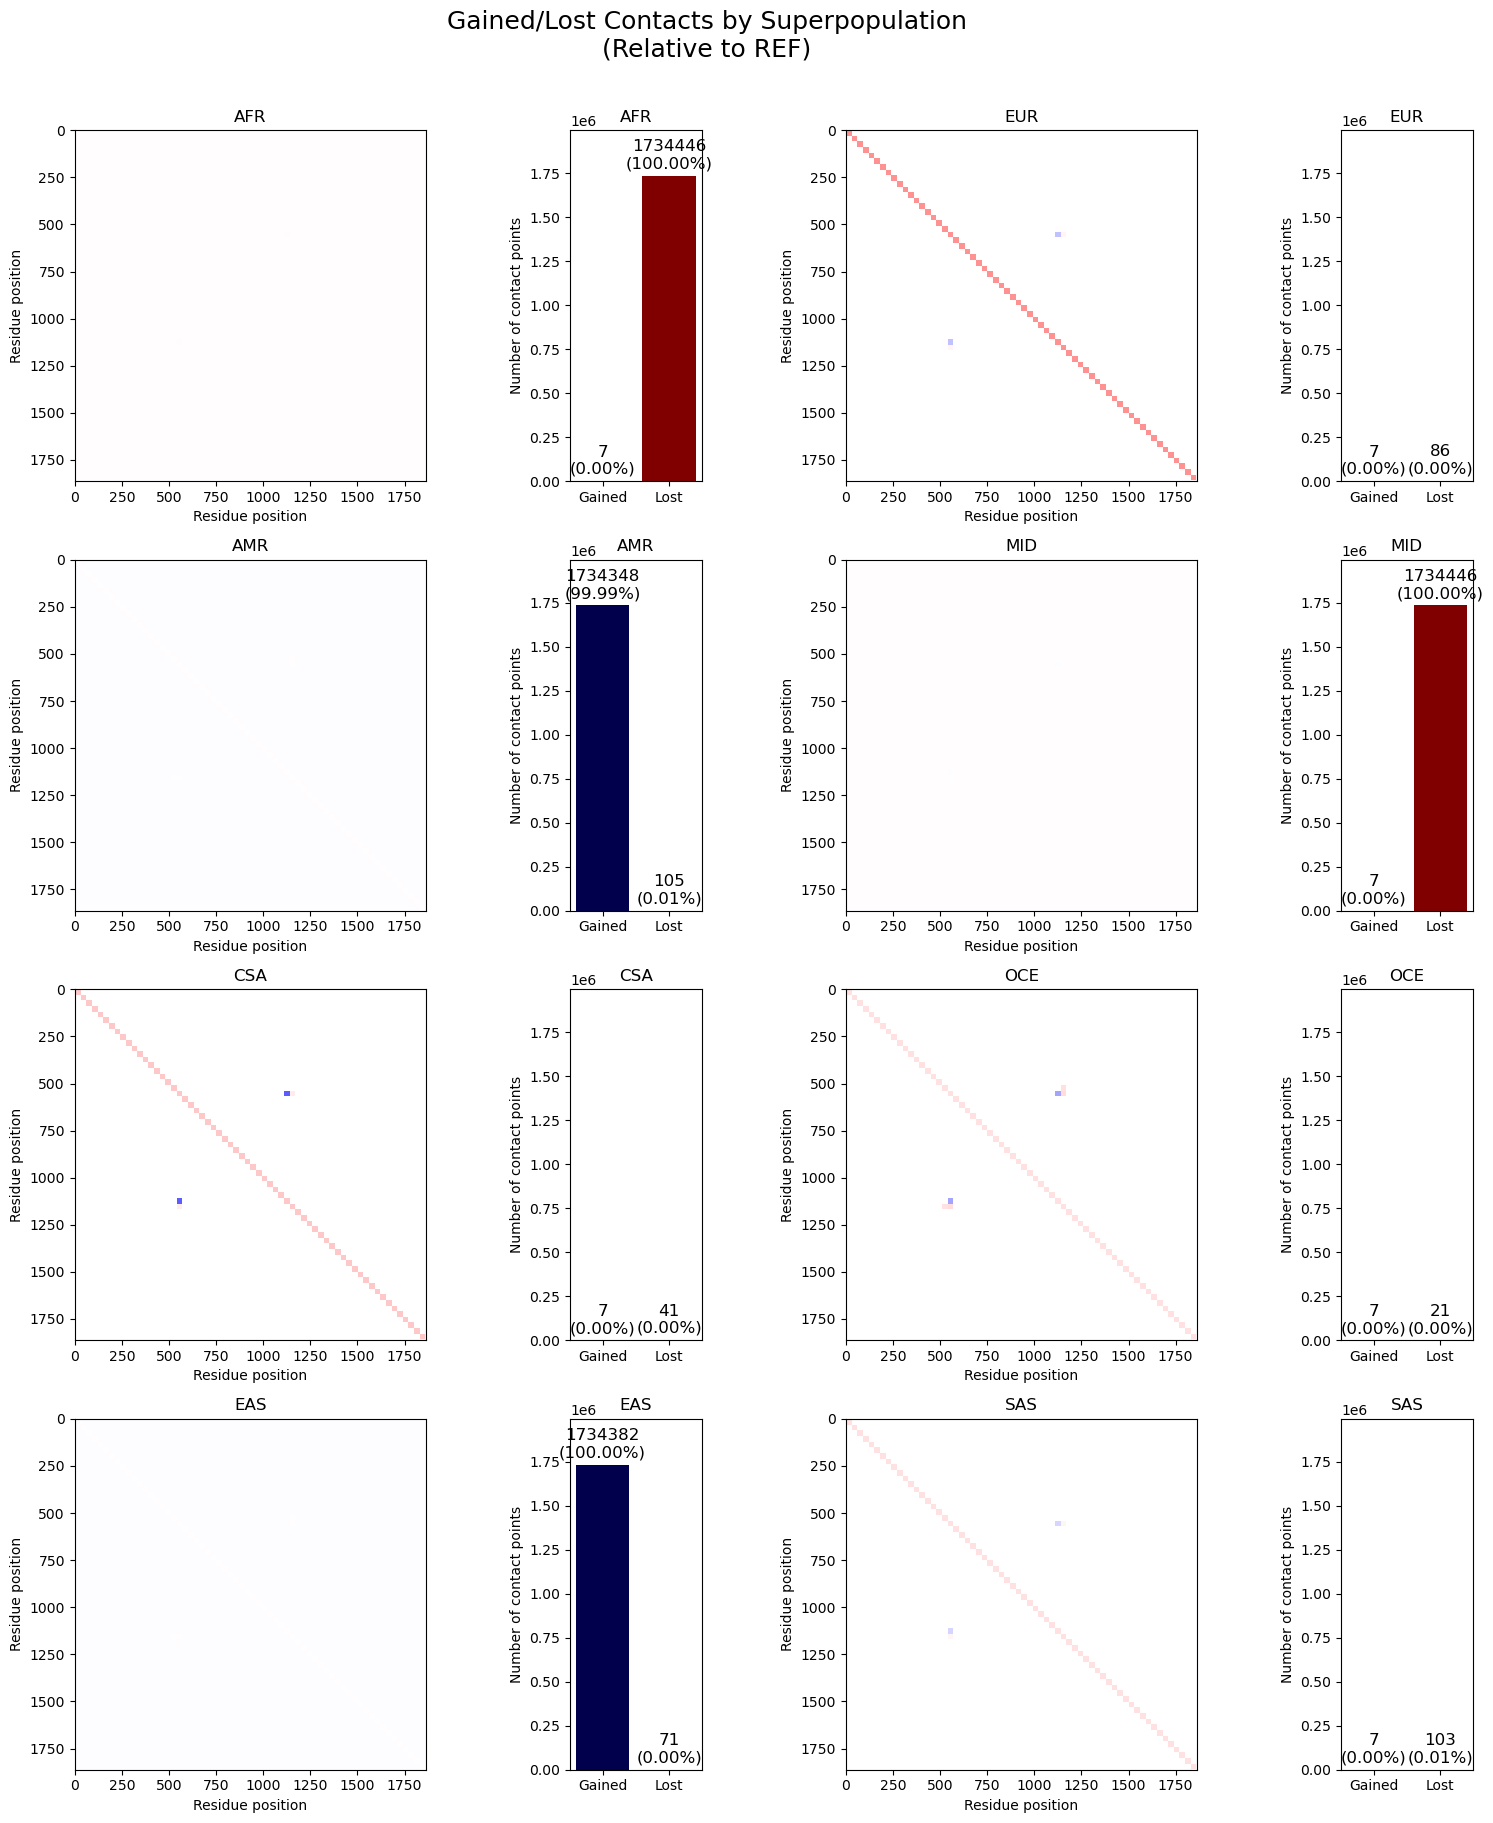

(<Figure size 1600x1800 with 16 Axes>,
      Type    Count    Percent superpopulation
 0  Gained        7   0.000404             AFR
 1    Lost  1734446  99.999596             AFR
 0  Gained  1734348  99.993946             AMR
 1    Lost      105   0.006054             AMR
 0  Gained        7   0.000404             CSA
 1    Lost       41   0.002364             CSA
 0  Gained  1734382  99.995906             EAS
 1    Lost       71   0.004094             EAS
 0  Gained        7   0.000404             EUR
 1    Lost       86   0.004958             EUR
 0  Gained        7   0.000404             MID
 1    Lost  1734446  99.999596             MID
 0  Gained        7   0.000404             OCE
 1    Lost       21   0.001211             OCE
 0  Gained        7   0.000404             SAS
 1    Lost      103   0.005938             SAS)

In [161]:
cf.plot_superpopulation_contact_diff(
    avg_binary_diff_figs,
    avg_binary_diff_maps, 
    use_common_heatmap_scale=True,
    set_common_barplot_ylim=True
)

Create stacked contact map examples for Figure 1.

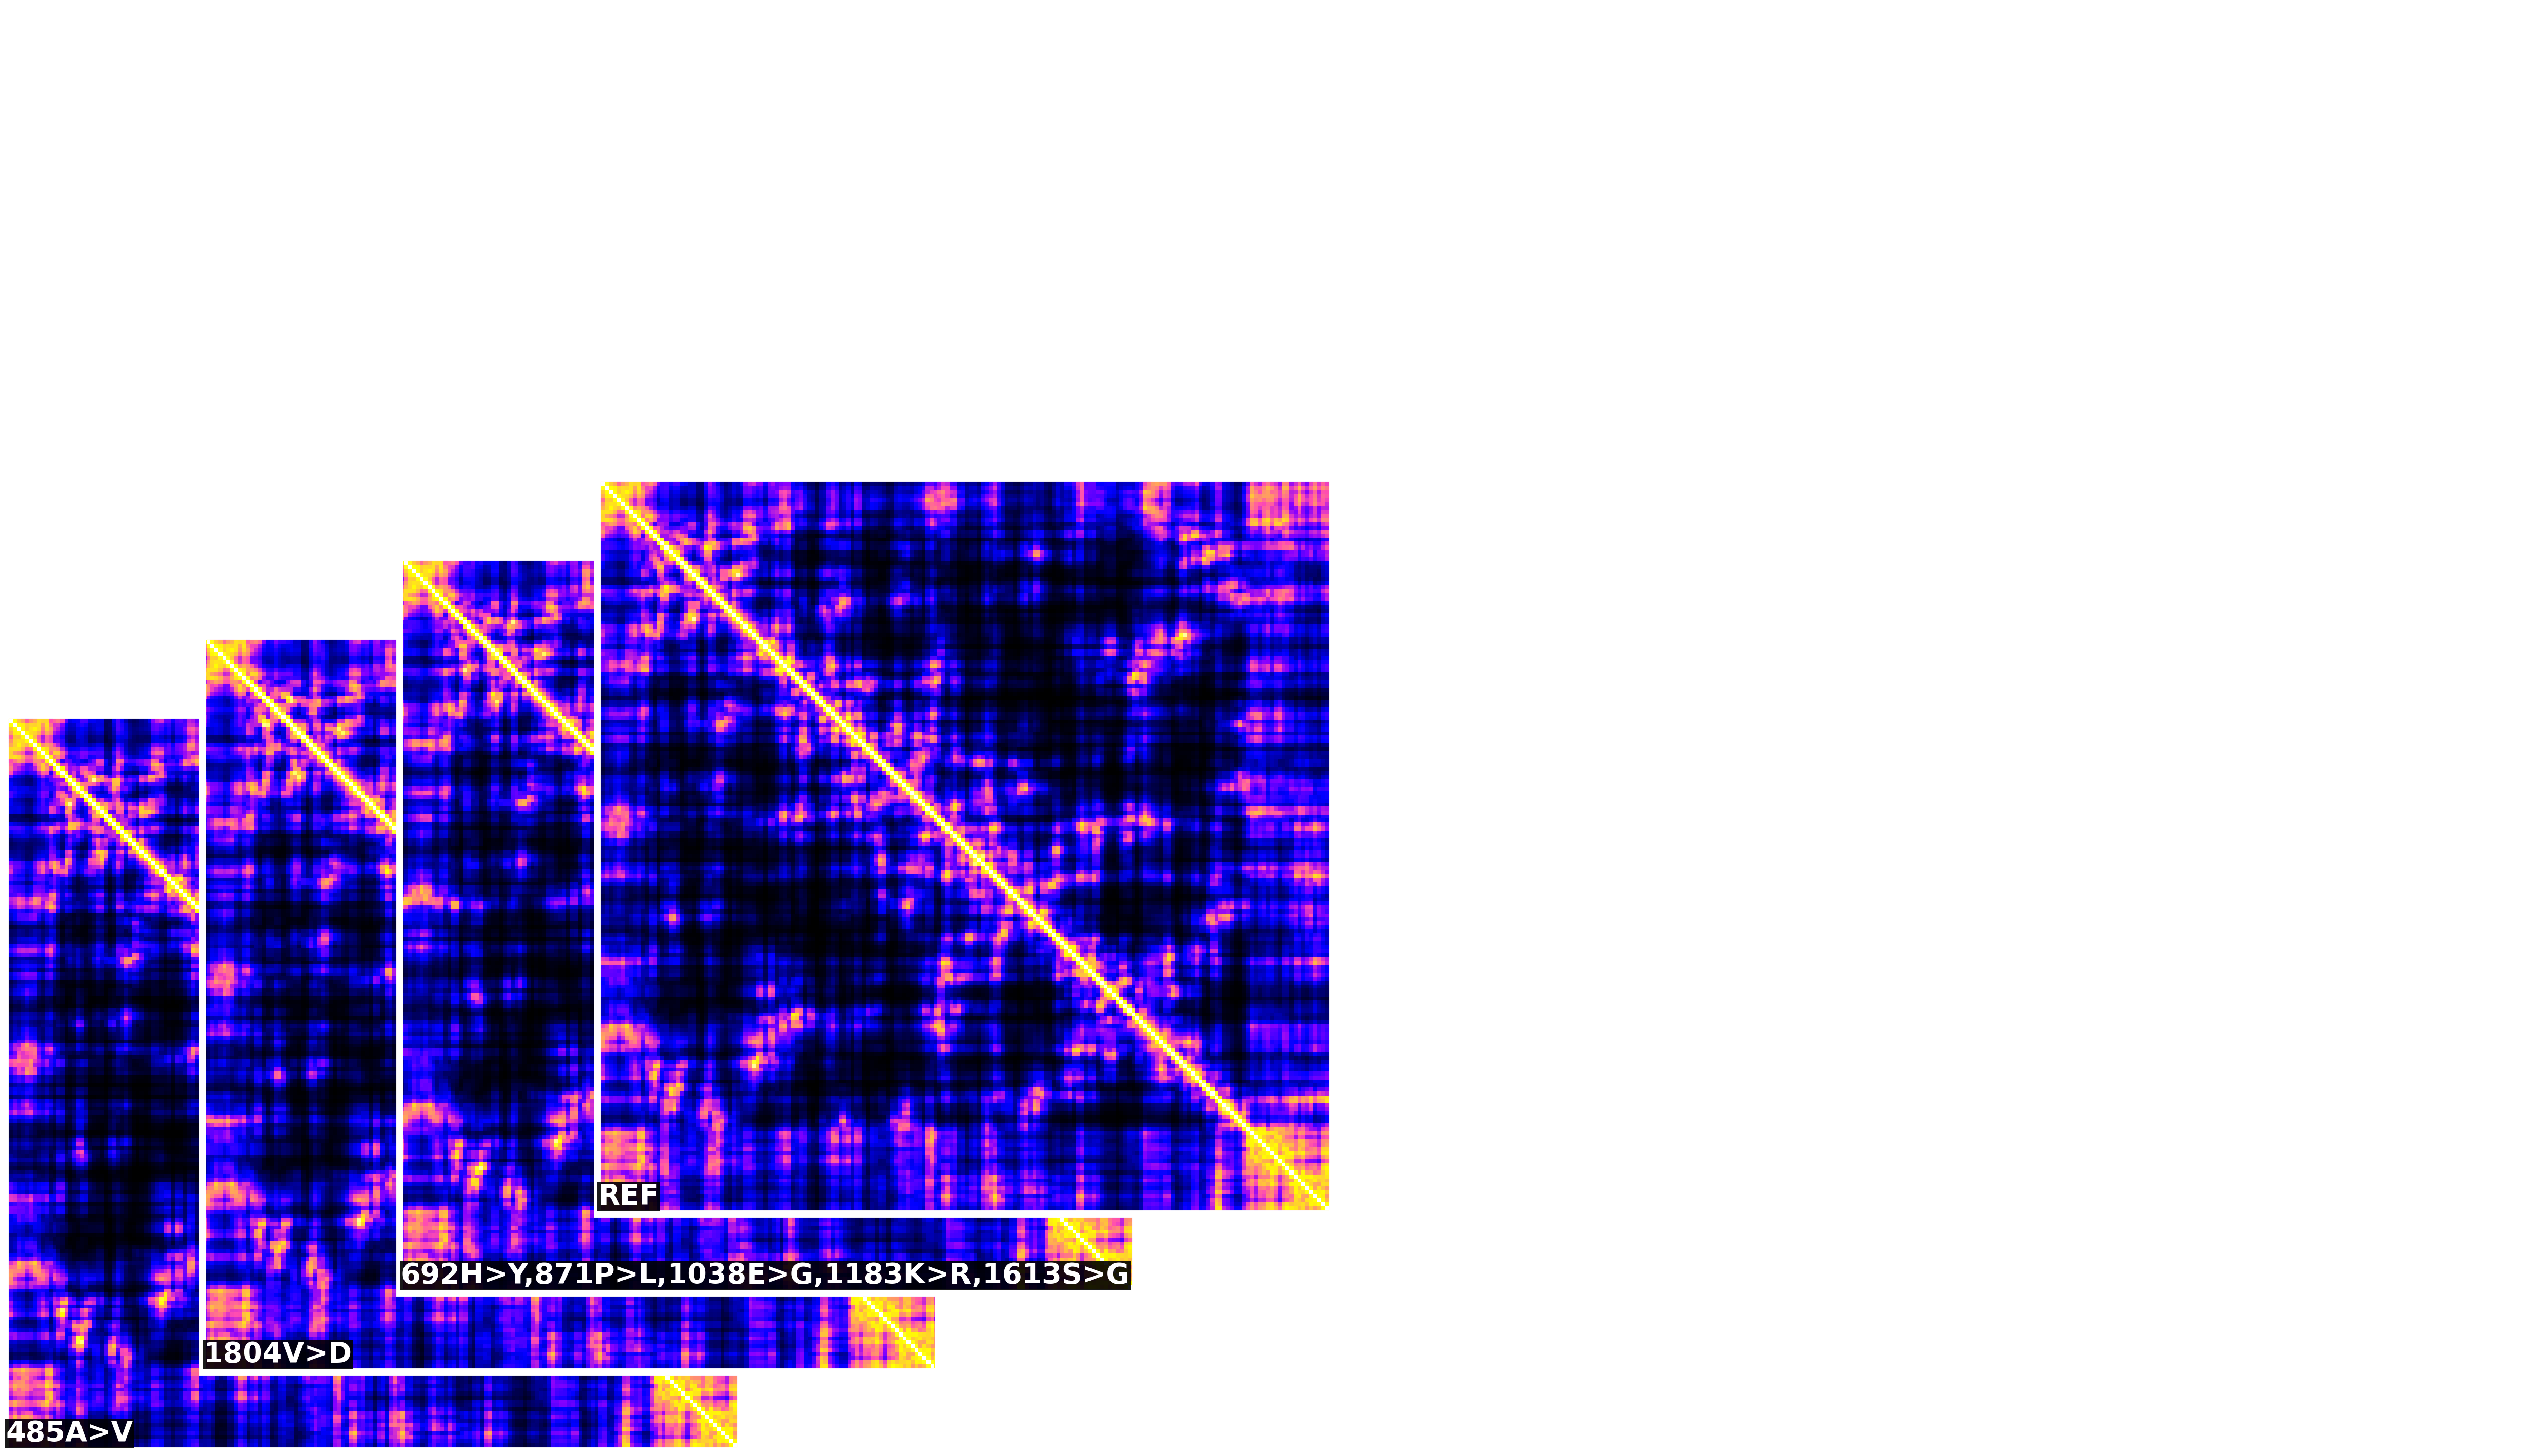

In [130]:
cf.plot_stacked_contact_maps(
    contact_maps, 
    n_maps=4, 
    front_on_top=True, 
    direction='ul2lr', 
    bin_size=10, 
    max_per_stack=10,
    stack_x_offset=1000,   # Example: 100 pixels horizontal offset between stacks
    stack_y_offset=30,     # Example: 30 pixels vertical offset between stacks
    stack_x_inner_offset=500,  # Example: 200 pixels horizontal offset within stack
    stack_y_inner_offset=200,   # Example: 40 pixels vertical offset within stack
    ref_on_top=True        # Ensure REF is the front-most plot
)


Created binary contact maps (0=no contact, 1=contact). 

Residue-residue euclidean distances of <8 Angstroms are considered contacts. 

In [49]:
contact_maps_binary = {}
for pdb_file in tqdm(pdb_files):
    structure = cf.import_pdb(pdb_file)
    contact_maps_binary[pdb_file] = cf.get_contact_map(structure, 
                                                continuous=False, 
                                                return_distance_map=False)

100%|██████████| 158/158 [00:16<00:00,  9.45it/s]


Entropy map shape: (1025, 1025)
Expanding x-axis by 5
Expanding y-axis by 5


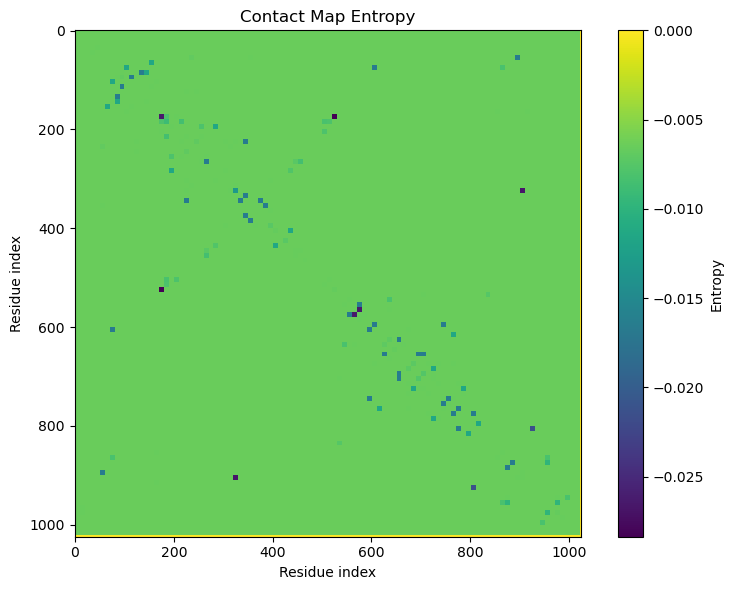

In [77]:
entropy_map = cf.plot_contact_map_entropy(contact_maps_binary, bin_size=10, agg_func=np.nanmean)

Difference-vs-REF map shape: (1863, 1863)
Expanding x-axis by 3
Expanding y-axis by 3


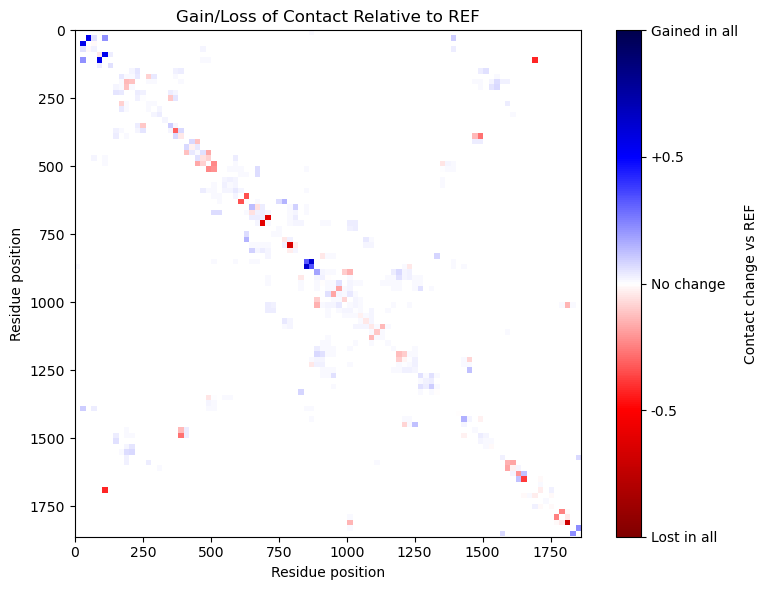

In [108]:
diff_map_fig, diff_map = cf.plot_contact_map_diff(contact_maps_binary) 

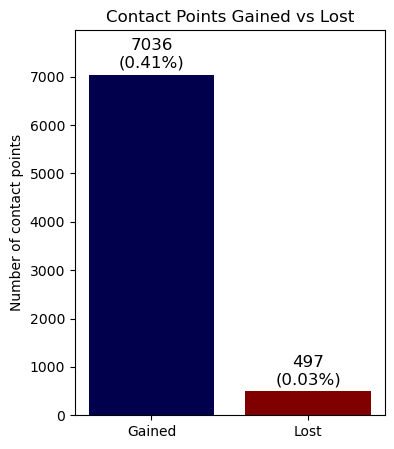

In [64]:
gained_lost_df = cf.plot_contact_map_diff_barplot(diff_map)

### Contact map variation: grid

 89%|████████▉ | 8/9 [00:01<00:00,  4.63it/s]


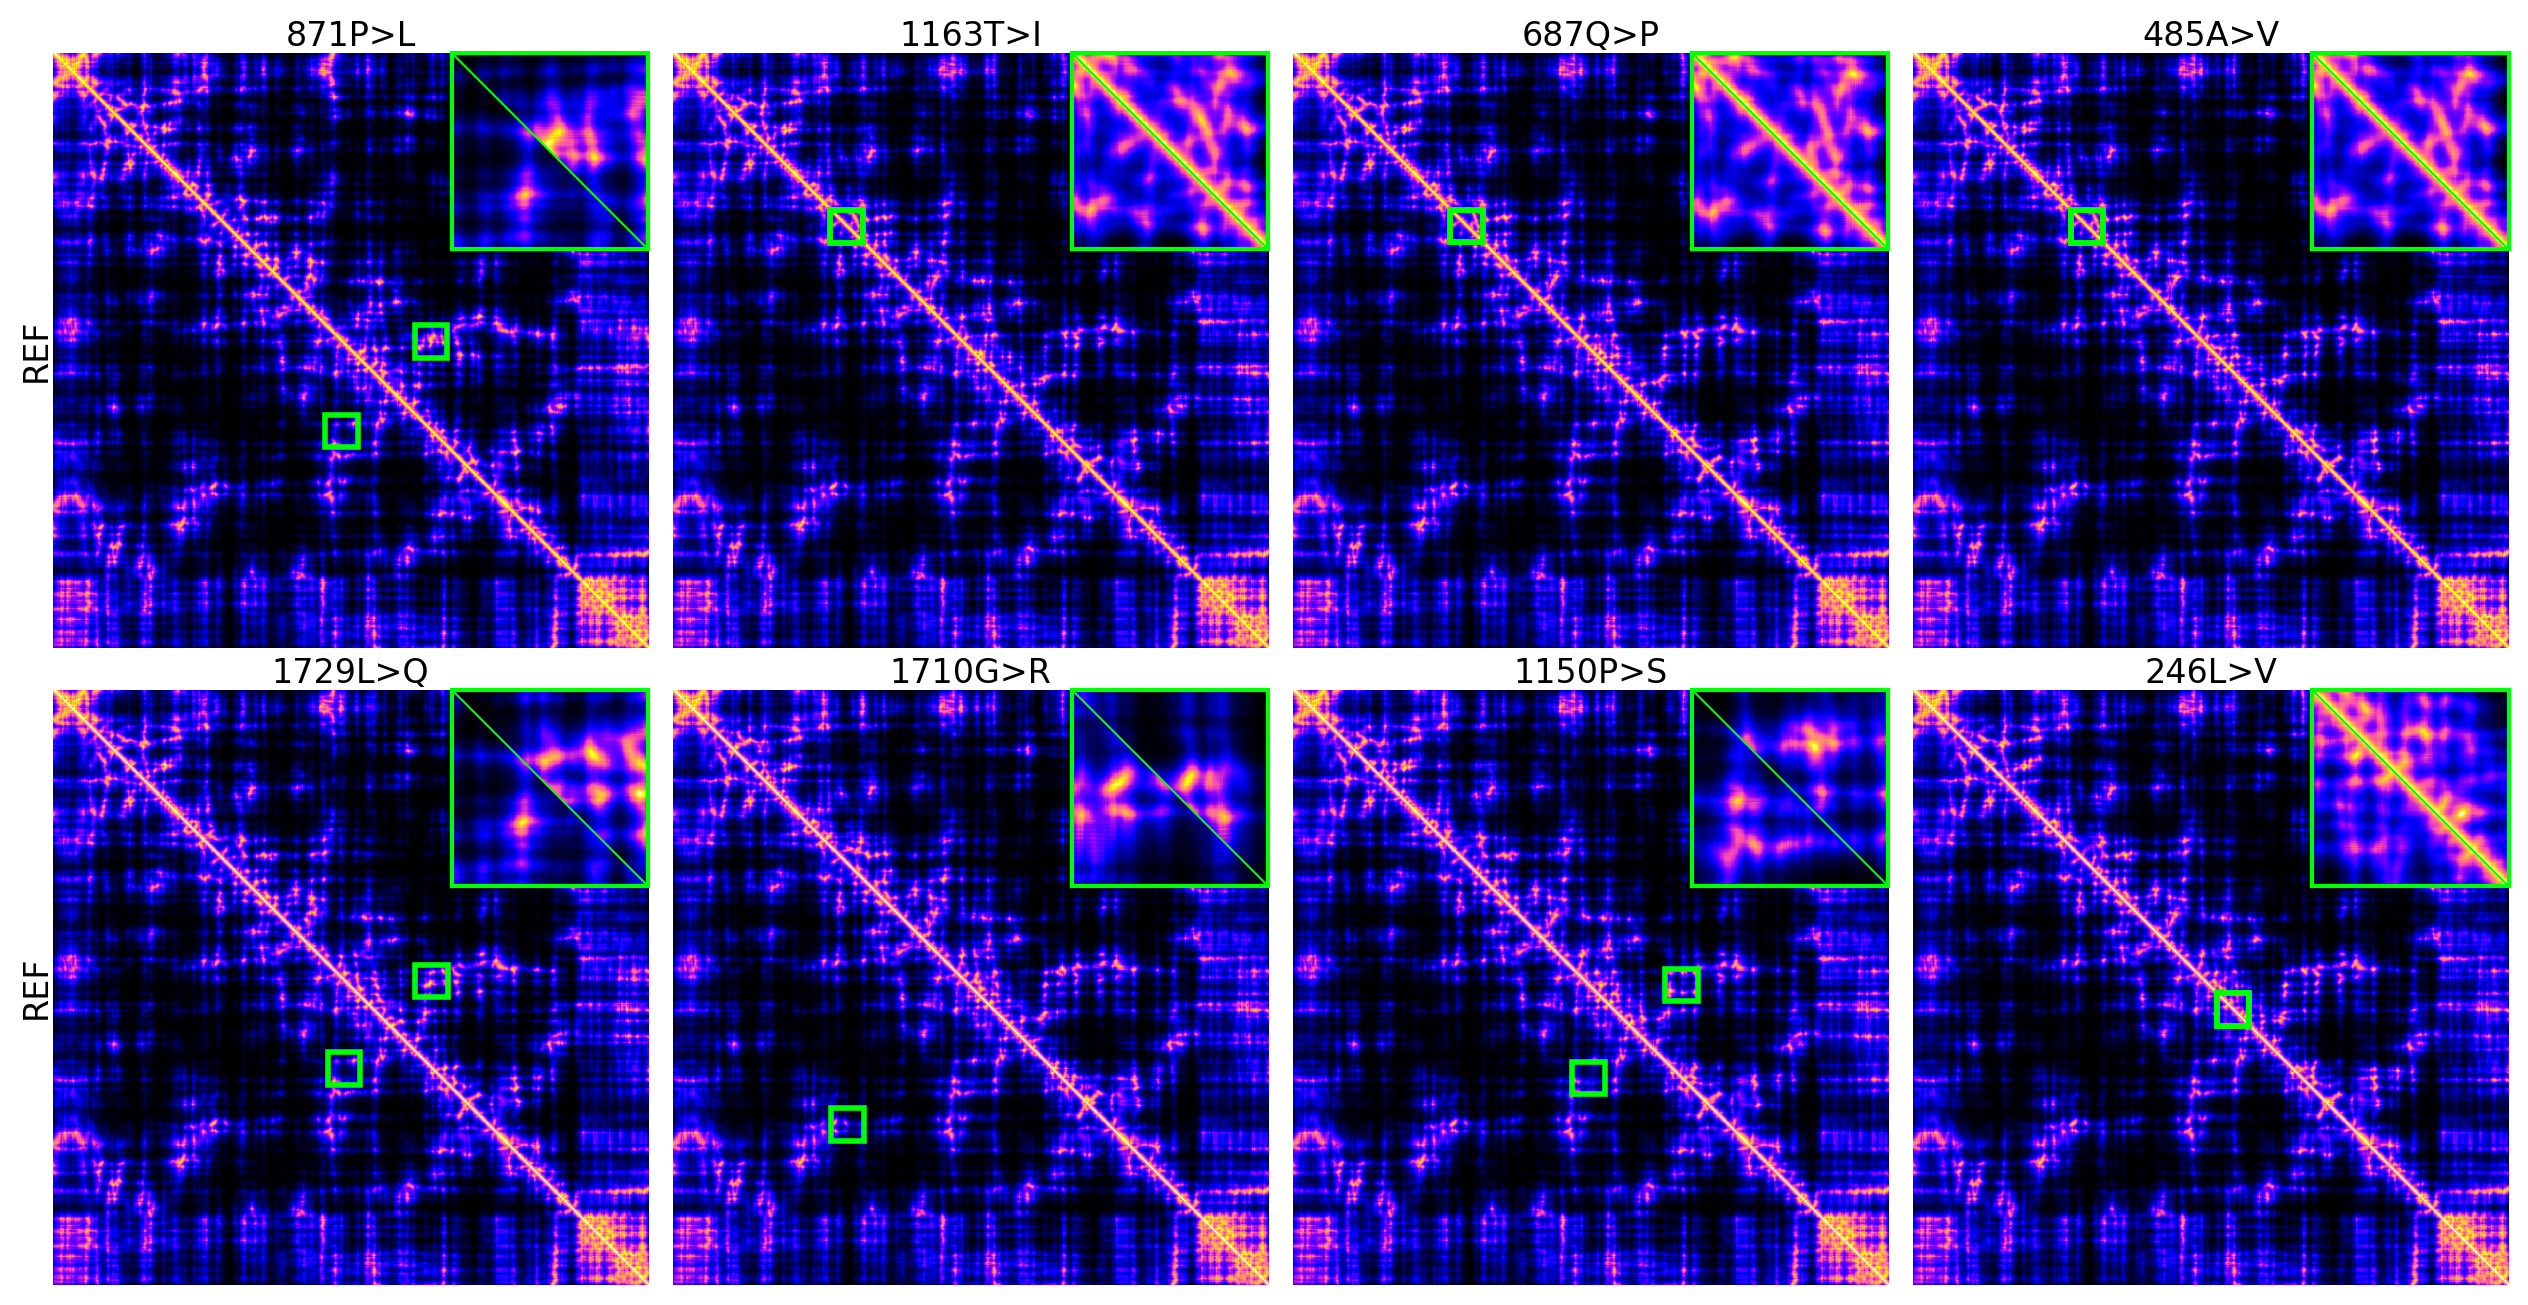

In [57]:
cf.plot_most_different_contact_maps(contact_maps, 
                                    max_subplots=9, 
                                    pow=4, 
                                    device="cuda:2",
                                    diff_mode="local",
                                    max_per_mutation=1,
                                    max_mutations=1,
                                    bin_size=1, 
                                    dpi=200,
                                    conv_window=100,
                                    # normalize=False,
                                    # agg_func=cf.nonzero_mean, 
                                    show_zoom_in=True,
                                    # highlight_min_size=100,
                                    highlight_postprocessed=True,
                                    highlight_n_regions=1,
                                    highlight_color="lime",
                                    highlight_linewidth=2, 
                                    highlight_box_offset=10,
                                    axis_title_fontsize=12,
                                    hspace=0.07, 
                                    split_ref_haplotype=True, 
                                    split_divider_params=None,
                                    highlight_diff_regions=True)

### Contact map variation: GIF

Create a GIF that shows each haplotype-specific contact map in random order.

In [64]:
frames = cf.animate_contact_maps_variation(contact_maps, 
                                           bin_size=2,
                                           output_path='results/plots/contact_maps_animation_DYPD.gif',
                                           n_frames=None)

100%|██████████| 158/158 [00:25<00:00,  6.31it/s]


### Contact map differences

Compute global distances between each pairwise combination of contact maps.

### Contact map interpolation

In [67]:
#  animate_contact_map_morphing_out = cf.animate_contact_map_morphing(contact_maps)


## Plot high-variance regions

Variance map shape: (1863, 1863)
Variance range: 8.275976 to 1574.594116


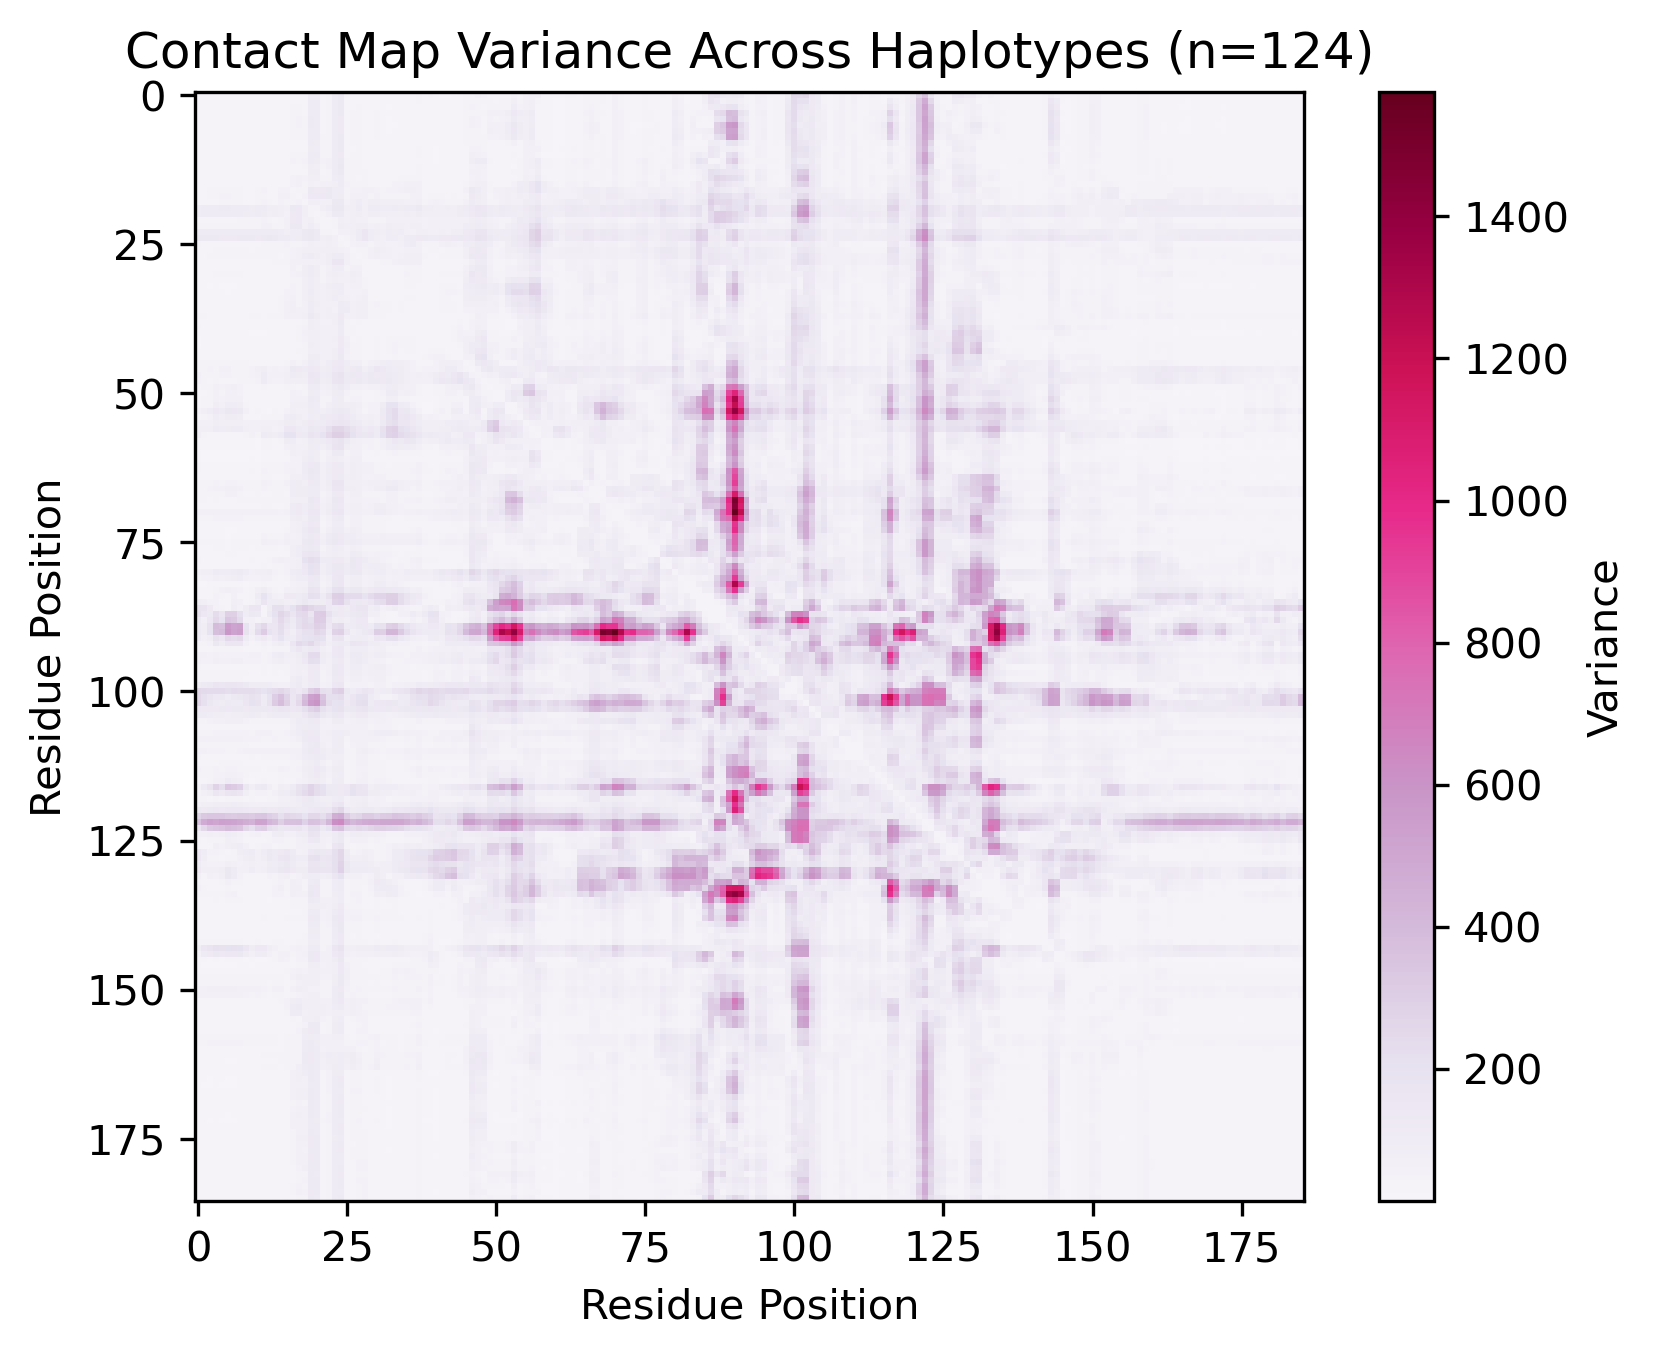

Top 10% variance threshold: 134.787811
Number of high-variance positions: 346890


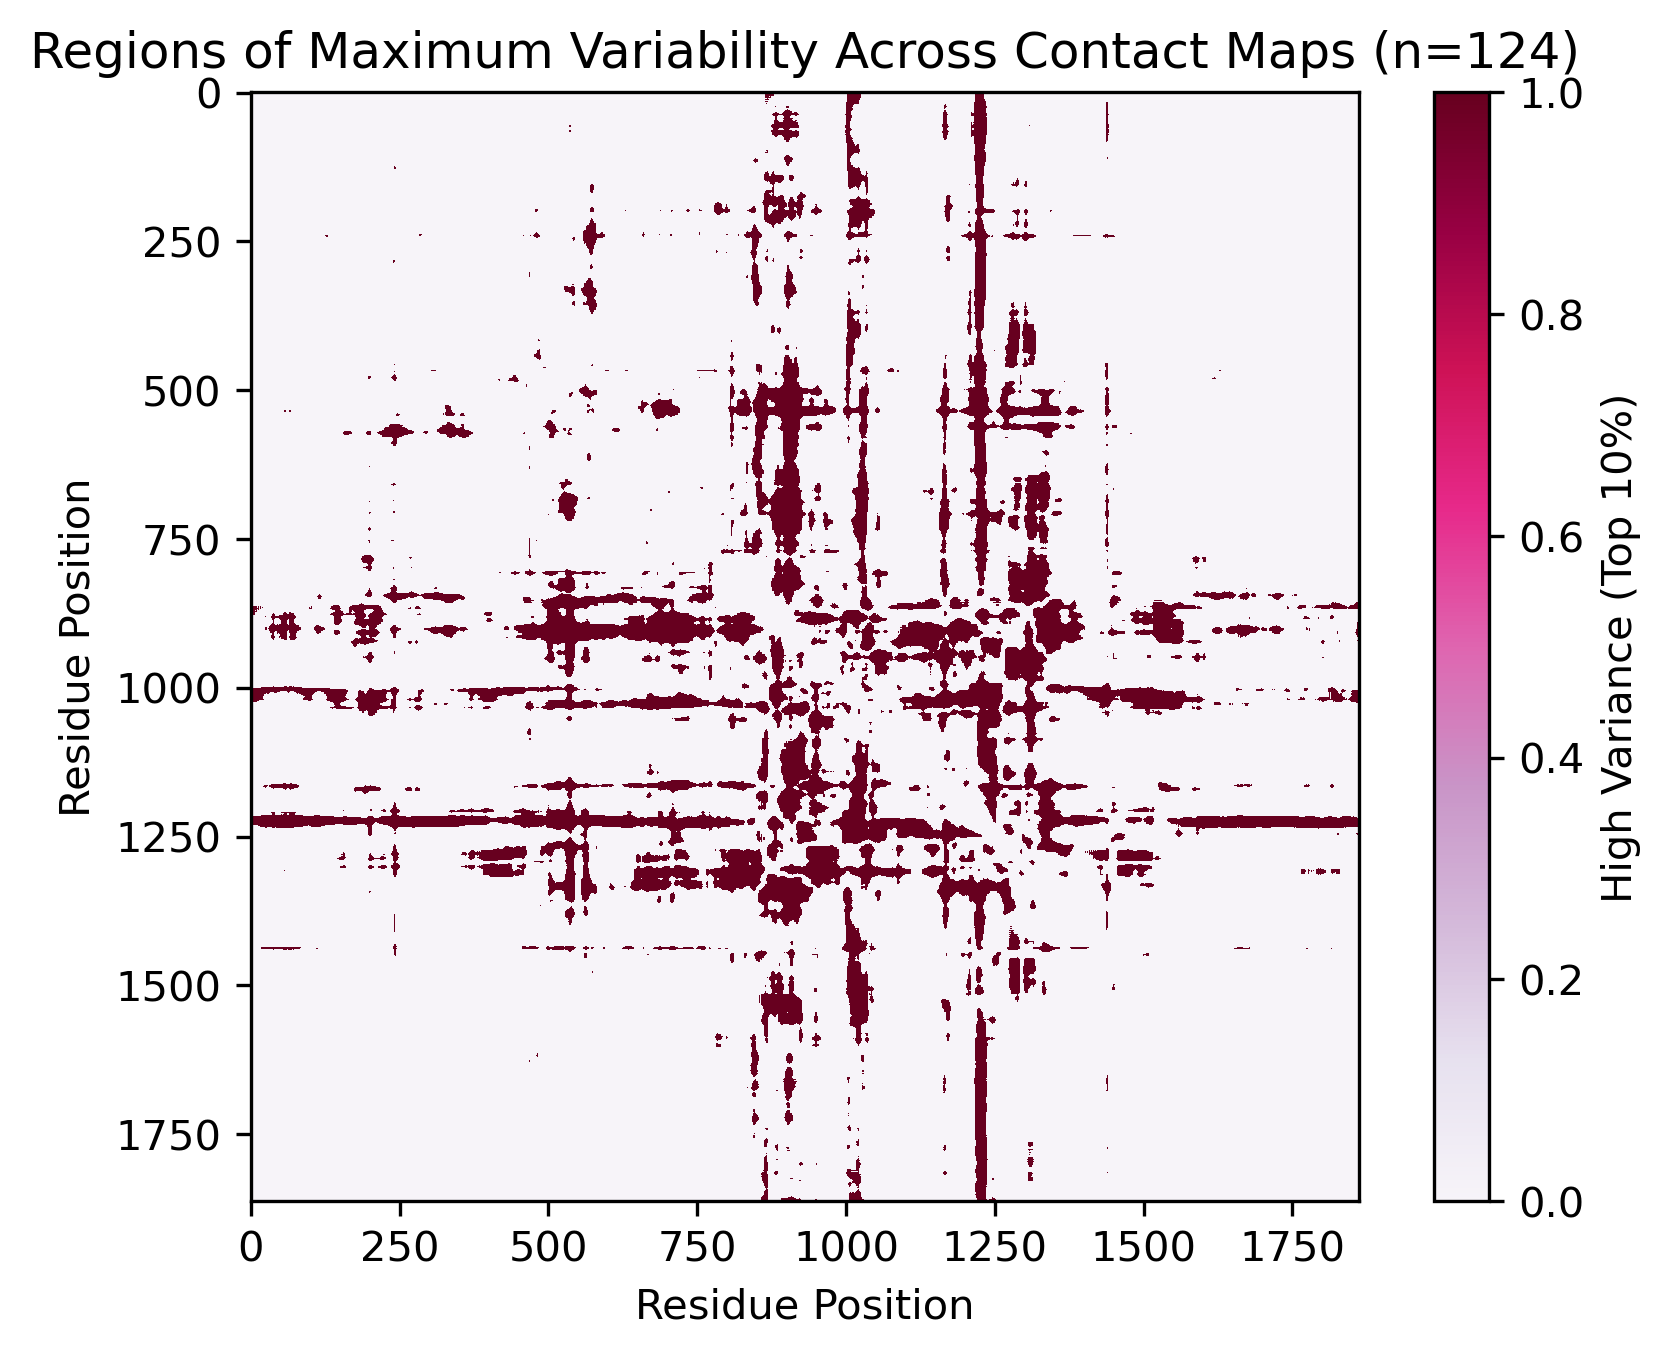

Coordinates of highest variance regions:
  Position (0, 872): variance = 142.107086
  Position (0, 873): variance = 143.743591
  Position (0, 874): variance = 155.245285
  Position (0, 875): variance = 162.426102
  Position (0, 876): variance = 156.400543
  Position (0, 877): variance = 152.816040
  Position (0, 1002): variance = 148.882370
  Position (0, 1003): variance = 187.357422
  Position (0, 1004): variance = 211.802353
  Position (0, 1005): variance = 232.785217


In [ ]:
# Compute variance across all contact maps to find maximally variable regions
import numpy as np

# Stack all contact maps into a 3D array
ref_len = len(contact_maps[cf.get_ref_key(contact_maps)])
contact_maps_array = np.stack([x for x in contact_maps.values() if len(x) == ref_len])

# Compute variance across the first dimension (across all contact maps)
variance_map = np.var(contact_maps_array, axis=0)

print(f"Variance map shape: {variance_map.shape}")
print(f"Variance range: {np.nanmin(variance_map):.6f} to {np.nanmax(variance_map):.6f}")
figsize=None
dpi=300

# Plot the variance map to visualize regions of high variability
plt.figure(figsize=figsize, dpi=dpi)

variance_map_binned = cf.bin_matrix(variance_map, bin_size=10)
plt.imshow(variance_map_binned, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='Variance')
plt.title(f'Contact Map Variance Across Haplotypes (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()

# Find the regions with highest variance, accounting for NaNs
# Get the top 10% of variance values, ignoring NaNs
variance_threshold = np.nanpercentile(variance_map, 90)
high_variance_mask = (variance_map > variance_threshold) & (~np.isnan(variance_map))

print(f"Top 10% variance threshold: {variance_threshold:.6f}")
print(f"Number of high-variance positions: {np.nansum(high_variance_mask)}")

# Plot high variance regions
plt.figure(figsize=figsize, dpi=dpi)
plt.imshow(high_variance_mask, cmap='PuRd', interpolation='nearest')
plt.colorbar(label='High Variance (Top 10%)')
plt.title(f'Regions of Maximum Variability Across Contact Maps (n={contact_maps_array.shape[0]})')
plt.xlabel('Residue Position')
plt.ylabel('Residue Position')
plt.show()

# Optional: Get coordinates of highest variance positions
high_variance_coords = np.where(high_variance_mask)
print(f"Coordinates of highest variance regions:")
for i in range(min(10, len(high_variance_coords[0]))):
    row, col = high_variance_coords[0][i], high_variance_coords[1][i]
    variance_value = variance_map[row, col]
    print(f"  Position ({row}, {col}): variance = {variance_value:.6f}")


### Get Predicted Aligned Error (PAE)

📘 What is PAE?
- predicted_aligned_error[i, j] = expected positional error in Ångströms at residue i when the predicted and true structures are aligned on residue j

- Asymmetric matrix: PAE[i,j] ≠ PAE[j,i]

- Useful for identifying flexible domains or low-confidence interdomain contacts

In [ ]:
import glob

base_dir = os.path.expanduser("~/projects/data/colabfold")
pae_files = glob.glob(os.path.join(base_dir,
                                   tx_id,
                                   "**", 
                                "af2_sameMSA/*_predicted_aligned_error_v1.json*"
                                   ),
                       recursive=True)
if len(pae_files) == 0:
    raise ValueError(f"No PAE files found for {tx_id}")

# Load PAE data from JSON file
pae_matrices = {}
for pae_file in tqdm(pae_files, desc="Loading PAE matrices"):
    pae_data = utils.load_json(pae_file, verbose=False)

    # Extract PAE matrix from the JSON structure
    # The exact structure depends on the JSON format, but typically it contains a 2D array
    if 'predicted_aligned_error' in pae_data:
        pae_matrices[pae_file] = np.array(pae_data['predicted_aligned_error']) 
    

Loading PAE matrices: 100%|██████████| 123/123 [00:57<00:00,  2.14it/s]


In [113]:
# Calculate mean PAE across all structures
pae_matrix = np.mean(np.array(list(pae_matrices.values())), axis=0)
     
print(f"PAE matrix shape: {pae_matrix.shape}")
print(f"PAE range: {np.min(pae_matrix):.3f} - {np.max(pae_matrix):.3f}")
print(f"Mean PAE: {np.mean(pae_matrix):.3f}")

PAE matrix shape: (1863, 1863)
PAE range: 0.250 - 31.290
Mean PAE: 27.433


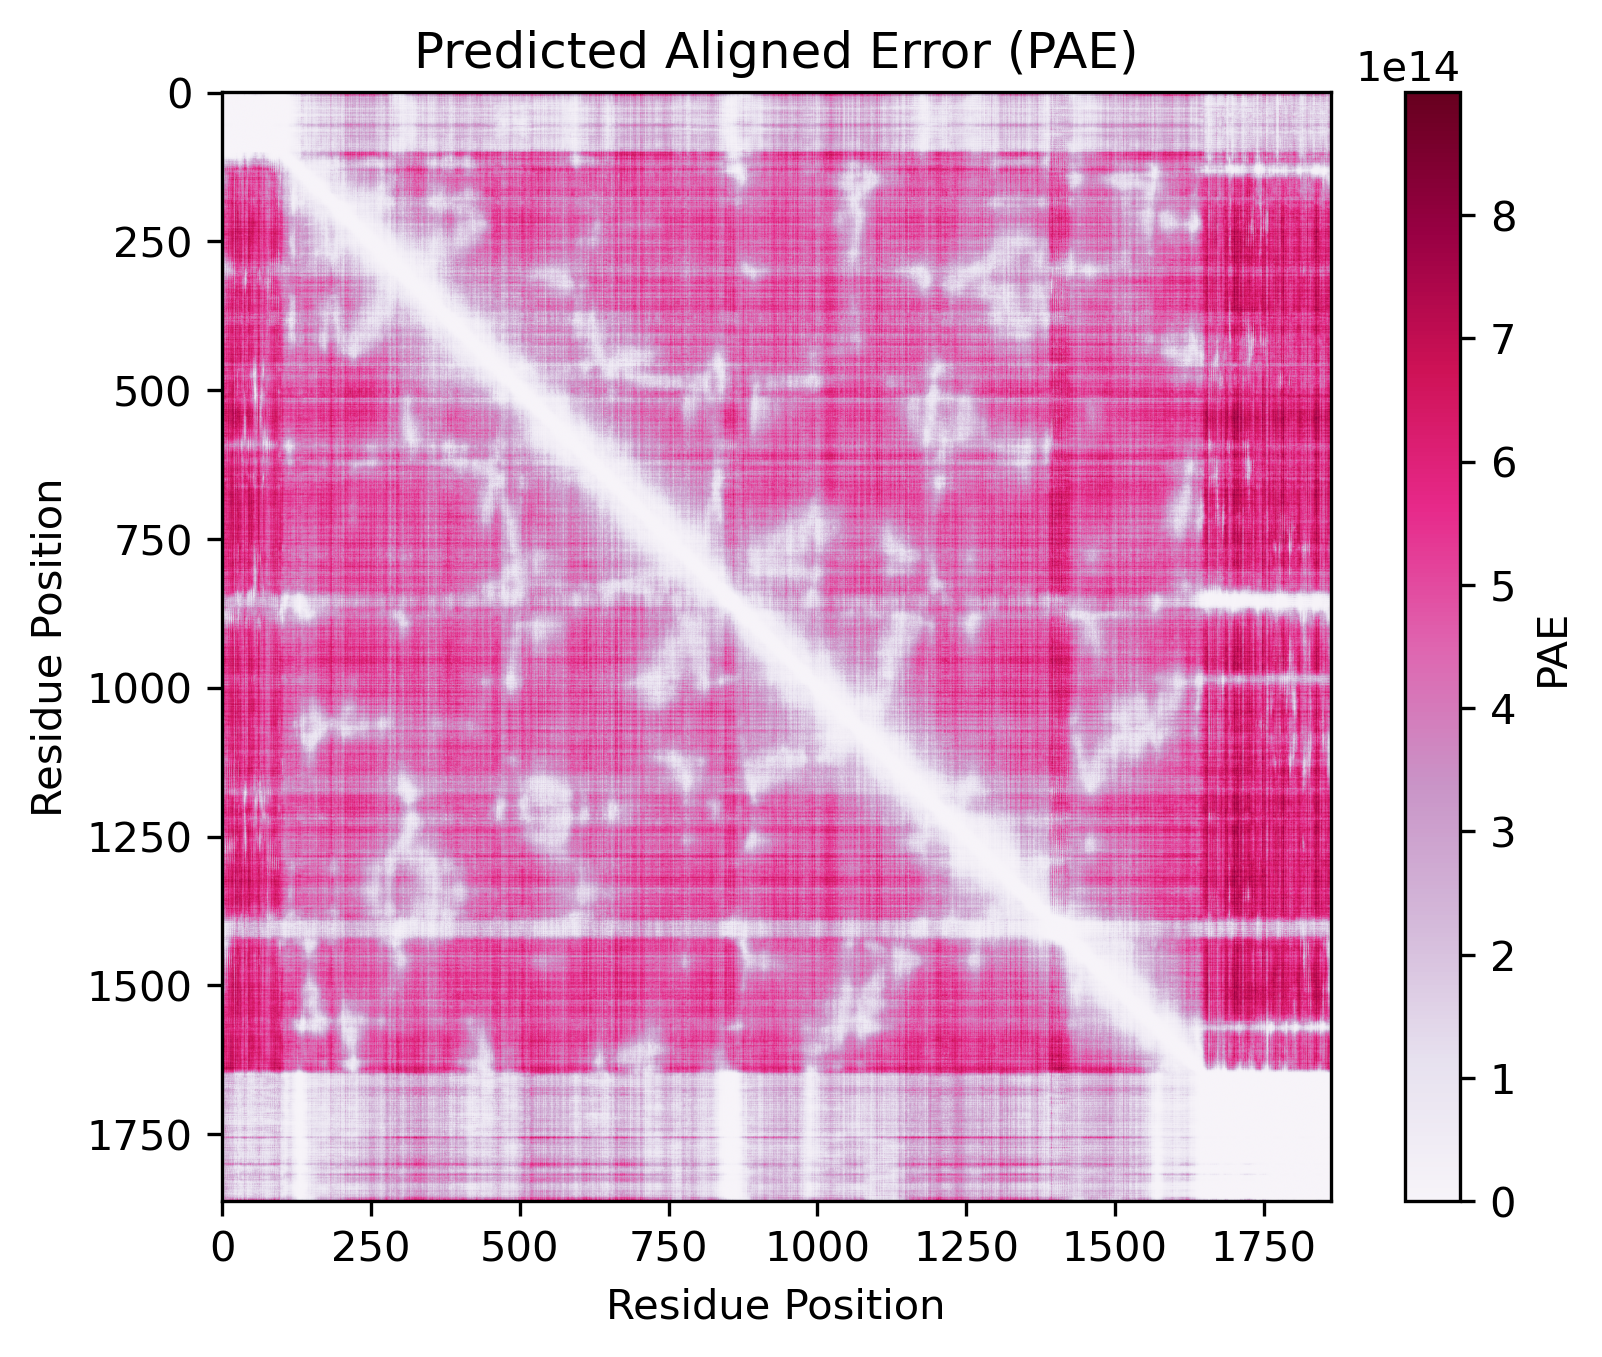

In [114]:
plt.figure(dpi=300)
plt.imshow(pae_matrix**10, cmap="PuRd")
plt.colorbar(label="PAE")
plt.title("Predicted Aligned Error (PAE)")
plt.xlabel("Residue Position")
plt.ylabel("Residue Position")
plt.show()

### Does Predicted Aligned Error correlate with contact map variance?

Pearson correlation: 0.0962 (p-value: 6.1985e-72)
Spearman correlation: 0.0422 (p-value: 4.1980e-15)
Linear fit R2: 0.0093


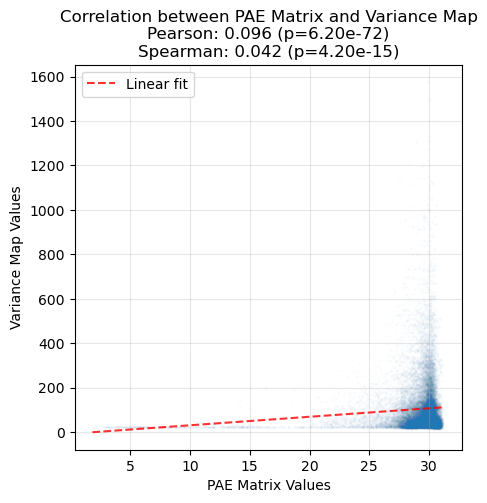


Interpretation: There is a weak positive correlation between PAE matrix and variance map values.


In [ ]:
cf.test_pae_variance_correlation(
    pae_matrix, 
    variance_map, 
    fit_exponential=False, 
    bin_size=10,
    log_x=False,   # Set to True to log-transform x (PAE)
    log_y=False    # Set to True to log-transform y (variance)
)


## AlphaFold embeddings

In [78]:
base_dir = os.path.expanduser("~/projects/data/colabfold")
npy_files = glob.glob(os.path.join(base_dir,
                                   tx_id,
                                   "**",
                                #  "af2_sameMSA/*_single_repr_*_model_1_*.npy"
                                 "af2_sameMSA/*_single_repr_rank*.npy"
                                # "af2_sameMSA/*_pair_repr_*_model_*.npy"
                                   ),
                       recursive=True)
print(len(npy_files),"files found")  

780 files found


In [79]:
import re

af2_meta = pd.DataFrame({'protein_id': [os.path.basename(x).split("_")[0] for x in npy_files],
 'sample_id': [os.path.basename(x).split("_single")[0].split("_", 1)[1] for x in npy_files],
 'model_id': [re.search(r'model_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_rank': [re.search(r'rank_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'model_seed': [re.search(r'seed_(\d+)', os.path.basename(x)).group(1) for x in npy_files],
 'file':npy_files}
 )

af2_meta.loc[:,"edit_distance"] = (af2_meta["sample_id"].str.count("_")+1)/2
af2_meta.loc[af2_meta["sample_id"]=="REF","edit_distance"] = 0
af2_meta.head()

,protein_id,sample_id,model_id,model_rank,model_seed,file,edit_distance
0,ENSP00000359211,342D_N_543I_V,4,002,000,/home/schilder/projects/data/colabfold/ENST000...,2.0
1,ENSP00000359211,29C_R_256I_M,4,002,000,/home/schilder/projects/data/colabfold/ENST000...,2.0
2,ENSP00000359211,543I_V_694I_V,3,001,000,/home/schilder/projects/data/colabfold/ENST000...,2.0
3,ENSP00000359211,438F_L_543I_V,1,005,000,/home/schilder/projects/data/colabfold/ENST000...,2.0
4,ENSP00000359211,543I_V_732V_I_1023P_T,2,004,000,/home/schilder/projects/data/colabfold/ENST000...,3.0


In [80]:
# Load all embeddings
embeddings = []
for npy_file in tqdm(npy_files, desc="Loading embeddings"):
    embedding = np.load(npy_file)
    # embedding = embedding.mean(axis=1).mean(axis=1)
    embeddings.append(embedding)

# Convert to numpy array
print("Converting to numpy array")
embeddings_array = np.array(embeddings)
print(f"Loaded {len(embeddings)} embeddings with shape: {embeddings_array.shape}")

# # Option to either flatten embeddings or take mean across sequence dimension
use_mean_embedding = True  # Set to False to flatten instead

if use_mean_embedding:
    # Take mean across sequence dimension (axis=1)
    # Each embedding is (seq_length, 128), we take mean to get (128,)
    embeddings_processed = np.mean(embeddings_array, axis=1)
    print(f"Mean embeddings shape: {embeddings_processed.shape}")
else:
    # Reshape embeddings for UMAP (flatten each embedding)
    # Each embedding is (seq_length, 256), we flatten to (seq_length * 256)
    embeddings_processed = embeddings_array.reshape(embeddings_array.shape[0], -1)
    print(f"Flattened embeddings shape: {embeddings_processed.shape}")



Loading embeddings: 100%|██████████| 780/780 [00:00<00:00, 1677.67it/s]


Converting to numpy array
Loaded 780 embeddings with shape: (780, 1025, 256)
Mean embeddings shape: (780, 256)


In [81]:
from sklearn.preprocessing import StandardScaler
# Standardize the data
scale = False
if scale:
    print("Standardizing data")
    scaler = StandardScaler()
    embeddings_scaled = scaler.fit_transform(embeddings_processed)
    print(f"Scaled embeddings shape: {embeddings_scaled.shape}")
else:
    embeddings_scaled = embeddings_processed

In [82]:
# Subset embeddings_scaled by indices where model_id == 1
model_1_indices = af2_meta[af2_meta['model_id'] == "1"].index 

In [83]:
import umap
import matplotlib.pyplot as plt

# Apply UMAP
print("Running UMAP") 

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=15, min_dist=0.1)
embeddings_2d = reducer.fit_transform(embeddings_scaled[model_1_indices])


Running UMAP


/home/schilder/.conda/envs/esm2/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [ ]:

af2_meta.loc[model_1_indices, "umap_1"] = embeddings_2d[:, 0]
af2_meta.loc[model_1_indices, "umap_2"] = embeddings_2d[:, 1]

def plot_umap(af2_meta, 
              color_col="edit_distance", 
              palette="plasma",
              alpha=0.8,
              interactive=False, **kwargs):
    if interactive:
        import plotly.express as px
        import plotly.graph_objects as go

        # Create the base scatter plot
        fig = px.scatter(af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                        x="umap_1", y="umap_2", 
                        color=color_col, 
                        hover_data=["protein_id", "sample_id", "model_rank", "model_seed"],
                        title="UMAP Visualization of AlphaFold Single Representations",
                        **kwargs)

        # Add red diamond markers for REF samples
        ref_data = af2_meta[af2_meta["sample_id"] == "REF"]
        fig.add_trace(go.Scatter(
            x=ref_data["umap_1"],
            y=ref_data["umap_2"],
            mode='markers',
            marker=dict(
                symbol='diamond',
                size=10,
                color='rgba(255,0,0,0)',  # Transparent red (no fill)
                line=dict(width=2, color='black')
            ),
            name='REF',
            showlegend=True,
            hoverinfo='skip'
        ))

        # Make the colorbar shorter and anchor to bottom
        fig.update_layout(
            coloraxis_colorbar=dict(
                len=0.6,  # Reduce colorbar length to 60% of default
                yanchor="bottom",
                y=0.0,
                title=dict(text="edit_distance".replace("_", "<br>"))
            )
        )

        fig.show()
    else:
        import matplotlib.pyplot as plt
        import seaborn as sns
        # Create visualization
        print("Creating visualization")
        plt.figure(figsize=(12, 8))
        sns.scatterplot(data=af2_meta.sort_values(by=["sample_id","model_id", "model_rank"]), 
                        x="umap_1", y="umap_2", 
                        hue=color_col, 
                        palette=palette,
                        alpha=alpha, 
                        s=50,
                        **kwargs)
        plt.title('UMAP Visualization of AlphaFold2 Single Representations')
        plt.xlabel('UMAP 1')
        plt.ylabel('UMAP 2')
        plt.grid(True, alpha=0.3)
        plt.show() 

plot_umap(af2_meta, interactive=True, color_col="edit_distance", width=600)

## Interactive UMAP with contact maps

In [ ]:
from src.colabfold import create_interactive_umap_with_contact_maps
from bokeh.plotting import show
from bokeh.io import output_notebook

# Enable Bokeh in Jupyter
output_notebook()

# Create interactive plot
layout = create_interactive_umap_with_contact_maps(
    af2_meta=af2_meta,
    contact_maps=contact_maps,
    use_bokeh=True,  # Use Bokeh instead of Plotly
    color_col='sample_id',
    hover_cols=['sample_id', 'edit_distance']
)

# Display in notebook
show(layout)

Loading BokehJS ...

 '1613S_G' '356Q_R_1512S_I' '1710G_R' '186S_Y_871P_L_1183K_R_1613S_G'
 '1801G_D' '179Y_C_486F_L_550N_H' '1783M_T' '1804V_D'
 '245D_Y_723N_D_871P_L_1183K_R_1613S_G'
 '332R_Q_871P_L_1038E_G_1183K_R_1613S_G' '356Q_R'
 '271V_M_871P_L_1038E_G_1183K_R_1613S_G' '228F_Y_871P_L'
 '191V_I_871P_L_1038E_G_1183K_R_1613S_G'
 '209P_L_871P_L_1038E_G_1183K_R_1613S_G' '246L_V'
 '275G_S_871P_L_1038E_G_1183K_R_1613S_G' '308S_T_871P_L_1140S_G'
 '356Q_R_1275I_V' '36S_Y_871P_L_1038E_G_1183K_R_1613S_G_1652M_I'
 '476H_R_820K_E_871P_L_1183K_R_1613S_G' '379I_M_871P_L'
 '411D_E_871P_L_1038E_G_1183K_R_1613S_G'
 '391E_Q_871P_L_1038E_G_1183K_R_1613S_G' '466R_Q'
 '596L_F_871P_L_1038E_G_1183K_R_1613S_G'
 '539T_M_871P_L_1038E_G_1183K_R_1613S_G'
 '504R_C_871P_L_1038E_G_1183K_R_1613S_G' '487V_F_871P_L'
 '504R_H_871P_L_1038E_G_1183K_R_1613S_G' '571I_M_871P_L'
 '571I_T_871P_L_1038E_G_1183K_R_1613S_G' '607K_E' '59S_L_356Q_R'] will be assigned to `nan_color` gray


Bokeh interactive plot created for Jupyter notebook.
Use show(layout) to display it in the notebook.


In [ ]:

from src.colabfold import create_dash_interactive_umap_app

# Create Dash app
app = create_dash_interactive_umap_app(
    af2_meta=af2_meta,
    contact_maps=contact_maps,
    color_col='population',
    size_col='confidence',
    hover_cols=['sample_id', 'edit_distance']
)

# Run the app
app.run(debug=True, port=8050)
# Open browser to http://localhost:8050